# Nhập dữ liệu từ thư mục `sic_2026`

Tôi sẽ đọc tất cả các tệp CSV trong thư mục `sic_2026`, sau đó nối chúng lại thành một DataFrame duy nhất.

In [186]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
!pip install squarify
import squarify
!pip install pyspellchecker
import matplotlib.pyplot as plt
import seaborn as sns

customer = pd.read_csv('/content/drive/MyDrive/sic_2026/indian_dataset/customer.csv')
card = pd.read_csv('/content/drive/MyDrive/sic_2026/indian_dataset/cards.csv')
merchant = pd.read_csv('/content/drive/MyDrive/sic_2026/indian_dataset/merchant.csv')
transaction = pd.read_csv('/content/drive/MyDrive/sic_2026/indian_dataset/transaction.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [187]:
# ============================================================
# BƯỚC 0: Xem trước cấu trúc từng bảng để biết tên cột thật
# ============================================================
for name, df in [("customer", customer), ("card", card),
                  ("merchant", merchant), ("transaction", transaction)]:
    print(f"\n=== {name} | {len(df):,} dòng | {df.shape[1]} cột ===")
    print(list(df.columns))
    print(df.head(2))


=== customer | 25,000 dòng | 12 cột ===
['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Marital_Status', 'Occupation', 'Annual_Income', 'Customer_Segment', 'State', 'City', 'Account_Type', 'Customer_Since']
  Customer_ID   Customer_Name  Gender  Age Marital_Status      Occupation  \
0  CUST100001  Omaja Majumdar  Female   27         Single  Police Officer   
1  CUST100002   Jason Agrawal  Female   41        Married         Teacher   

   Annual_Income Customer_Segment           State    City Account_Type  \
0        1167132             Gold   Uttar Pradesh    Agra      Savings   
1         493532         Standard  Madhya Pradesh  Ujjain       Salary   

  Customer_Since  
0     2017-11-13  
1     2020-05-05  

=== card | 32,457 dòng | 10 cột ===
['Card_ID', 'Customer_ID', 'Card_Type', 'Card_Network', 'Credit_Limit', 'Card_Status', 'Contactless', 'Card_Mode', 'Issue_Date', 'Expiry_Date']
      Card_ID Customer_ID Card_Type Card_Network  Credit_Limit Card_Status  \
0  CARD500001  CUS

## Tạo bản sao của dữ liệu gốc

In [188]:
c_orig = customer.copy()
cd_orig = card.copy()
m_orig = merchant.copy()
t_orig = transaction.copy()

# Hiện trạng dữ liệu

## Kiểm tra giá trị null, trùng lặp

In [189]:
def check_data(data):
  quality_dict = {
      'missingvalue' : data.isnull().sum().to_dict(),
      'duplication' : data.duplicated().sum(),
      'đata infor' : data.info()
  }
  return quality_dict

In [190]:
response = check_data(c_orig)
display(response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Customer_ID       25000 non-null  object
 1   Customer_Name     25000 non-null  object
 2   Gender            25000 non-null  object
 3   Age               25000 non-null  int64 
 4   Marital_Status    25000 non-null  object
 5   Occupation        25000 non-null  object
 6   Annual_Income     25000 non-null  int64 
 7   Customer_Segment  25000 non-null  object
 8   State             25000 non-null  object
 9   City              25000 non-null  object
 10  Account_Type      25000 non-null  object
 11  Customer_Since    25000 non-null  object
dtypes: int64(2), object(10)
memory usage: 2.3+ MB


{'missingvalue': {'Customer_ID': 0,
  'Customer_Name': 0,
  'Gender': 0,
  'Age': 0,
  'Marital_Status': 0,
  'Occupation': 0,
  'Annual_Income': 0,
  'Customer_Segment': 0,
  'State': 0,
  'City': 0,
  'Account_Type': 0,
  'Customer_Since': 0},
 'duplication': np.int64(0),
 'đata infor': None}

In [191]:
response = check_data(cd_orig)
display(response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32457 entries, 0 to 32456
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Card_ID       32457 non-null  object
 1   Customer_ID   32457 non-null  object
 2   Card_Type     32457 non-null  object
 3   Card_Network  32457 non-null  object
 4   Credit_Limit  32457 non-null  int64 
 5   Card_Status   32457 non-null  object
 6   Contactless   32457 non-null  object
 7   Card_Mode     32457 non-null  object
 8   Issue_Date    32457 non-null  object
 9   Expiry_Date   32457 non-null  object
dtypes: int64(1), object(9)
memory usage: 2.5+ MB


{'missingvalue': {'Card_ID': 0,
  'Customer_ID': 0,
  'Card_Type': 0,
  'Card_Network': 0,
  'Credit_Limit': 0,
  'Card_Status': 0,
  'Contactless': 0,
  'Card_Mode': 0,
  'Issue_Date': 0,
  'Expiry_Date': 0},
 'duplication': np.int64(0),
 'đata infor': None}

In [192]:
response = check_data(m_orig)
display(response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Merchant_ID          500 non-null    object 
 1   Merchant_Name        500 non-null    object 
 2   Merchant_Category    500 non-null    object 
 3   State                500 non-null    object 
 4   City                 500 non-null    object 
 5   Merchant_Risk_Level  500 non-null    object 
 6   Merchant_Rating      500 non-null    float64
 7   Merchant_Status      500 non-null    object 
 8   Merchant_Since       500 non-null    object 
dtypes: float64(1), object(8)
memory usage: 35.3+ KB


{'missingvalue': {'Merchant_ID': 0,
  'Merchant_Name': 0,
  'Merchant_Category': 0,
  'State': 0,
  'City': 0,
  'Merchant_Risk_Level': 0,
  'Merchant_Rating': 0,
  'Merchant_Status': 0,
  'Merchant_Since': 0},
 'duplication': np.int64(0),
 'đata infor': None}

In [193]:
response = check_data(t_orig)
display(response)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Transaction_ID       250000 non-null  object 
 1   Customer_ID          250000 non-null  object 
 2   Card_ID              250000 non-null  object 
 3   Merchant_ID          250000 non-null  object 
 4   Transaction_Date     250000 non-null  object 
 5   Transaction_Time     250000 non-null  object 
 6   Transaction_Amount   250000 non-null  float64
 7   Payment_Method       250000 non-null  object 
 8   Transaction_Channel  250000 non-null  object 
 9   Device_Type          250000 non-null  object 
 10  Transaction_Status   250000 non-null  object 
 11  Is_International     250000 non-null  int64  
 12  Fraud_Flag           250000 non-null  int64  
 13  Fraud_Reason         13473 non-null   object 
 14  Merchant_Risk_Level  250000 non-null  object 
 15  Merchant_Category

{'missingvalue': {'Transaction_ID': 0,
  'Customer_ID': 0,
  'Card_ID': 0,
  'Merchant_ID': 0,
  'Transaction_Date': 0,
  'Transaction_Time': 0,
  'Transaction_Amount': 0,
  'Payment_Method': 0,
  'Transaction_Channel': 0,
  'Device_Type': 0,
  'Transaction_Status': 0,
  'Is_International': 0,
  'Fraud_Flag': 0,
  'Fraud_Reason': 236527,
  'Merchant_Risk_Level': 0,
  'Merchant_Category': 0,
  'Customer_State': 0,
  'Customer_City': 0,
  'Merchant_State': 0,
  'Merchant_City': 0},
 'duplication': np.int64(0),
 'đata infor': None}

## Thay null thành NaN

In [194]:
# Thay thế các giá trị None hoặc chuỗi rỗng '' thành np.nan trong cột 'Fraud_Reason'
t_orig['Fraud_Reason'] = t_orig['Fraud_Reason'].replace(['', None], np.nan)

# Kiểm tra lại số lượng giá trị thiếu sau khi xử lý
print(f"Số lượng giá trị thiếu trong cột 'Fraud_Reason' sau xử lý: {t_orig['Fraud_Reason'].isna().sum()}")

Số lượng giá trị thiếu trong cột 'Fraud_Reason' sau xử lý: 236527


## Tỉ lệ Fraud_Flag

In [195]:
display(pd.DataFrame({
    "Values" : t_orig["Fraud_Flag"].value_counts(),
    "Percentage" : t_orig["Fraud_Flag"].value_counts(normalize=True) * 100
}))

,Values,Percentage
Fraud_Flag,,
0,236527,94.6108
1,13473,5.3892


## Kiểm tra khoá chính

In [196]:
print(c_orig["Customer_ID"].is_unique)
print(cd_orig["Card_ID"].is_unique)
print(m_orig["Merchant_ID"].is_unique)
print(t_orig["Transaction_ID"].is_unique)

True
True
True
True


## Kiểm tra khoá ngoại (FK)

In [197]:
print(t_orig["Customer_ID"].isin(c_orig["Customer_ID"]).all())
print(t_orig["Card_ID"].isin(cd_orig["Card_ID"]).all())
print(t_orig["Merchant_ID"].isin(m_orig["Merchant_ID"]).all())
print(cd_orig["Customer_ID"].isin(c_orig["Customer_ID"]).all())

True
True
True
True


## Kiểm tra lỗi chính tả bằng pyspellchecker

In [198]:
from spellchecker import SpellChecker

spell = SpellChecker(language='en') # Khởi tạo trình kiểm tra chính tả với ngôn ngữ tiếng Anh

# Chọn một cột dữ liệu để kiểm tra, ví dụ 'Merchant_Name' từ m_orig
# Lọc các giá trị không phải null và chuyển thành danh sách các từ duy nhất
merchant_names = c_orig['Marital_Status'].dropna().unique()

# Một số tên có thể có nhiều từ, chúng ta cần tách chúng ra
words_to_check = []
for name in merchant_names:
    words_to_check.extend(name.split())

# Tìm các từ sai chính tả
misspelled = spell.unknown(words_to_check)

print(f"Số lượng từ sai chính tả tiềm năng: {len(misspelled)}")
print("Các từ sai chính tả tiềm năng:")
for word in list(misspelled)[:10]: # In ra 10 từ đầu tiên để xem xét
    print(f"- {word}")


Số lượng từ sai chính tả tiềm năng: 1
Các từ sai chính tả tiềm năng:
- divorsed


## Chuyển định dạng thời gian

In [199]:
t_orig["Transaction_Date"] = pd.to_datetime(t_orig["Transaction_Date"])
cd_orig["Issue_Date"] = pd.to_datetime(cd_orig["Issue_Date"])
c_orig["Customer_Since"] = pd.to_datetime(c_orig["Customer_Since"])
cd_orig["Expiry_Date"] = pd.to_datetime(cd_orig["Expiry_Date"])
m_orig["Merchant_Since"] = pd.to_datetime(m_orig["Merchant_Since"])

## Xem định dạng thời gian

In [200]:
print(t_orig["Transaction_Date"])
print(cd_orig["Issue_Date"])
print(cd_orig["Expiry_Date"])
print(c_orig["Customer_Since"])
print(m_orig["Merchant_Since"])

0        2024-03-03
1        2023-11-08
2        2023-01-11
3        2023-05-25
4        2023-10-22
            ...    
249995   2026-05-18
249996   2026-02-26
249997   2026-05-11
249998   2023-10-19
249999   2025-08-28
Name: Transaction_Date, Length: 250000, dtype: datetime64[ns]
0       2021-04-24
1       2020-06-30
2       2022-04-04
3       2020-07-21
4       2024-07-24
           ...    
32452   2019-02-10
32453   2020-09-08
32454   2023-06-16
32455   2018-11-02
32456   2018-09-18
Name: Issue_Date, Length: 32457, dtype: datetime64[ns]
0       2026-04-24
1       2025-06-30
2       2027-04-04
3       2025-07-21
4       2029-07-24
           ...    
32452   2024-02-10
32453   2025-09-08
32454   2028-06-16
32455   2023-11-02
32456   2023-09-18
Name: Expiry_Date, Length: 32457, dtype: datetime64[ns]
0       2017-11-13
1       2020-05-05
2       2023-08-23
3       2018-05-21
4       2017-04-16
           ...    
24995   2021-12-09
24996   2021-07-19
24997   2020-04-25
24998   2021-12-27

# Thu thập, hợp nhất dữ liệu (Data Integration)

## Đọc file

In [201]:
c_orig.info()
cd_orig.info()
m_orig.info()
t_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Customer_ID       25000 non-null  object        
 1   Customer_Name     25000 non-null  object        
 2   Gender            25000 non-null  object        
 3   Age               25000 non-null  int64         
 4   Marital_Status    25000 non-null  object        
 5   Occupation        25000 non-null  object        
 6   Annual_Income     25000 non-null  int64         
 7   Customer_Segment  25000 non-null  object        
 8   State             25000 non-null  object        
 9   City              25000 non-null  object        
 10  Account_Type      25000 non-null  object        
 11  Customer_Since    25000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 2.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32457 entries, 0

## Gộp bảng

In [202]:
m_cols = [
    "Merchant_ID",
    "Merchant_Name",
    "Merchant_Rating",
    "Merchant_Status",
    "Merchant_Since"
]

df_merged = t_orig.merge(
    c_orig,
    on='Customer_ID',
    how='left'
).merge(
    cd_orig,
    on=["Customer_ID", "Card_ID"],
    how='left'
).merge(
    m_orig[m_cols],
    on="Merchant_ID",
    how="left"
)

Kiểm tra dữ liệu sau gộp

In [203]:
print(df_merged.shape)
df_merged.head()
df_merged.info()

(250000, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 43 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Transaction_ID       250000 non-null  object        
 1   Customer_ID          250000 non-null  object        
 2   Card_ID              250000 non-null  object        
 3   Merchant_ID          250000 non-null  object        
 4   Transaction_Date     250000 non-null  datetime64[ns]
 5   Transaction_Time     250000 non-null  object        
 6   Transaction_Amount   250000 non-null  float64       
 7   Payment_Method       250000 non-null  object        
 8   Transaction_Channel  250000 non-null  object        
 9   Device_Type          250000 non-null  object        
 10  Transaction_Status   250000 non-null  object        
 11  Is_International     250000 non-null  int64         
 12  Fraud_Flag           250000 non-null  int64         
 13  F

In [204]:
missing = df_merged.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": round((missing / len(df_merged)) * 100, 2)
})

,Missing Values,Percentage
Fraud_Reason,236527,94.61


In [205]:
df_merged.duplicated().sum()

np.int64(0)

In [206]:
df_merged.describe(include="object").T

,count,unique,top,freq
Transaction_ID,250000,250000,TXN1249984,1
Customer_ID,250000,24902,CUST121815,39
Card_ID,250000,32292,CARD509956,26
Merchant_ID,250000,500,MER100345,567
Transaction_Time,250000,81562,00:00:00,1786
Payment_Method,250000,4,Debit Card,127789
Transaction_Channel,250000,4,POS,120284
Device_Type,250000,6,POS Terminal,120284
Transaction_Status,250000,3,Successful,227821
Fraud_Reason,13473,8,Transaction Attempt on Expired Card,2470


# Làm sạch (Data Cleaning)

## Sửa chính tả

In [207]:
c_orig['Marital_Status'] = c_orig['Marital_Status'].replace(['Divorsed'], ['Divorced'])

## Kiểm tra chính tả lại

In [208]:
merchant_names = c_orig['Marital_Status'].dropna().unique()

words_to_check = []
for name in merchant_names:
    words_to_check.extend(name.split())

misspelled = spell.unknown(words_to_check)

print(f"Số lượng từ sai chính tả tiềm năng: {len(misspelled)}")
print("Các từ sai chính tả tiềm năng:")
for word in list(misspelled)[:10]: # In ra 10 từ đầu tiên để xem xét
    print(f"- {word}")

Số lượng từ sai chính tả tiềm năng: 0
Các từ sai chính tả tiềm năng:


## Chuẩn hóa dữ liệu văn bản (Text Normalization)

Chúng ta sẽ xử lý các cột có kiểu dữ liệu `object` (chuỗi) để loại bỏ khoảng trắng thừa

In [209]:
# Lấy danh sách các cột có kiểu dữ liệu là 'object' từ df_merged
object_cols = df_merged.select_dtypes(include=['object']).columns

print("Đang chuẩn hóa các cột sau:")
for col in object_cols:
    print(f"- {col}")
    # Áp dụng .str.strip() để loại bỏ khoảng trắng thừa
    df_merged[col] = df_merged[col].astype(str).str.strip()

print("\nHoàn tất chuẩn hóa văn bản.")
# Kiểm tra một số cột sau khi chuẩn hóa để đảm bảo
print("\nKiểm tra một số giá trị sau chuẩn hóa:")
display(df_merged[['Gender', 'Marital_Status', 'Occupation', 'State', 'City']].head())

Đang chuẩn hóa các cột sau:
- Transaction_ID
- Customer_ID
- Card_ID
- Merchant_ID
- Transaction_Time
- Payment_Method
- Transaction_Channel
- Device_Type
- Transaction_Status
- Fraud_Reason
- Merchant_Risk_Level
- Merchant_Category
- Customer_State
- Customer_City
- Merchant_State
- Merchant_City
- Customer_Name
- Gender
- Marital_Status
- Occupation
- Customer_Segment
- State
- City
- Account_Type
- Card_Type
- Card_Network
- Card_Status
- Contactless
- Card_Mode
- Merchant_Name
- Merchant_Status

Hoàn tất chuẩn hóa văn bản.

Kiểm tra một số giá trị sau chuẩn hóa:


,Gender,Marital_Status,Occupation,State,City
0,Female,Single,Nurse,Tamil Nadu,Madurai
1,Male,Married,Chartered Accountant,Kerala,Kollam
2,Female,Single,Lawyer,Uttar Pradesh,Agra
3,Female,Married,Doctor,Punjab,Ludhiana
4,Female,Married,Teacher,Maharashtra,Thane


## Xử lý trùng lặp & tính nhất quán (Deduplication & Consistency)

In [210]:
# 1. Loại bỏ dòng trùng hoàn toàn
initial_rows = df_merged.shape[0]
df_merged.drop_duplicates(inplace=True)
removed_rows = initial_rows - df_merged.shape[0]
print(f"Số lượng dòng trùng lặp đã loại bỏ: {removed_rows}")
print(f"Số lượng dòng còn lại sau khi loại bỏ trùng lặp: {df_merged.shape[0]}")

Số lượng dòng trùng lặp đã loại bỏ: 0
Số lượng dòng còn lại sau khi loại bỏ trùng lặp: 250000


In [211]:
# 2. Kiểm tra khóa chính không trùng lặp trong df_merged
print(f"Transaction_ID có duy nhất trong df_merged không? {df_merged['Transaction_ID'].is_unique}")

Transaction_ID có duy nhất trong df_merged không? True


## Kiểm tra tính nhất quán tham chiếu (Referential Integrity)
Chúng ta sẽ kiểm tra xem tất cả các Customer_ID, Card_ID, Merchant_ID trong `df_merged` có tồn tại trong các bảng gốc tương ứng (`c_orig`, `cd_orig`, `m_orig`) hay không. Vì `df_merged` được tạo bằng phép nối (left join), các ID này về lý thuyết phải tồn tại.

In [212]:
customer_id_integrity = df_merged['Customer_ID'].isin(c_orig['Customer_ID'].str.lower()).all()
print(f"Tất cả Customer_ID trong df_merged có tồn tại trong c_orig không? {customer_id_integrity}")

card_id_integrity = df_merged['Card_ID'].isin(cd_orig['Card_ID'].str.lower()).all()
print(f"Tất cả Card_ID trong df_merged có tồn tại trong cd_orig không? {card_id_integrity}")

merchant_id_integrity = df_merged['Merchant_ID'].isin(m_orig['Merchant_ID'].str.lower()).all()
print(f"Tất cả Merchant_ID trong df_merged có tồn tại trong m_orig không? {merchant_id_integrity}")

Tất cả Customer_ID trong df_merged có tồn tại trong c_orig không? False
Tất cả Card_ID trong df_merged có tồn tại trong cd_orig không? False
Tất cả Merchant_ID trong df_merged có tồn tại trong m_orig không? False


#Xử lý ngoại lai (Outlier Treatment) & Kiểm tra phân phối dữ liệu

##`Transaction_Amount`: Phát hiện giao dịch bất thường lớn

--- Phát hiện ngoại lệ cho cột 'Transaction_Amount' bằng phương pháp IQR ---
Q1 (25th percentile): 1,000.00
Q3 (75th percentile): 18,309.91
IQR: 17,309.91
Giới hạn dưới: -24,964.86
Giới hạn trên: 44,274.77
Số lượng ngoại lệ được phát hiện: 24,641
Tỷ lệ ngoại lệ: 9.86%
Dưới đây là 5 ngoại lệ đầu tiên (hoặc tất cả nếu ít hơn 5):


,Transaction_ID,Customer_ID,Card_ID,Merchant_ID,Transaction_Date,Transaction_Time,Transaction_Amount,Payment_Method,Transaction_Channel,Device_Type,...,Credit_Limit,Card_Status,Contactless,Card_Mode,Issue_Date,Expiry_Date,Merchant_Name,Merchant_Rating,Merchant_Status,Merchant_Since
3,TXN1000004,CUST109049,CARD511773,MER100053,2023-05-25,01:48:56,52694.99,Credit Card,POS,POS Terminal,...,1411749,Active,Yes,Physical,2020-10-31,2025-10-31,PhonePe,4.4,Active,2011-06-25
6,TXN1000007,CUST117124,CARD522230,MER100428,2025-10-05,17:55:46,83430.87,Debit Card,ATM,ATM Machine,...,66295,Active,Yes,Physical,2024-03-18,2029-03-18,Coursera,3.5,Active,2023-01-03
7,TXN1000008,CUST117464,CARD522663,MER100037,2025-08-04,06:02:59,47447.47,Debit Card,ATM,ATM Machine,...,260914,Active,Yes,Physical,2022-03-02,2027-03-02,SpiceJet,4.0,Active,2011-07-11
20,TXN1000021,CUST115845,CARD520588,MER100284,2026-01-22,08:49:29,253850.67,UPI,Mobile App,Android Mobile,...,289811,Active,Yes,Physical,2025-10-25,2030-10-25,Jio-bp,4.2,Active,2022-06-24
32,TXN1000033,CUST101949,CARD502535,MER100005,2023-12-22,23:03:40,79179.14,UPI,Mobile App,Android Mobile,...,137112,Active,Yes,Physical,2019-06-30,2024-06-30,IndiGo,4.1,Active,2007-07-18


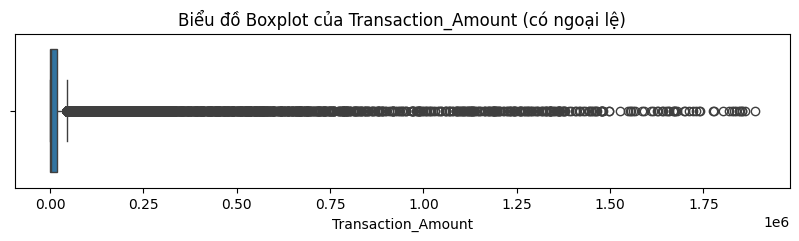

In [213]:
def display_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"--- Phát hiện ngoại lệ cho cột '{column}' bằng phương pháp IQR ---")
    print(f"Q1 (25th percentile): {Q1:,.2f}")
    print(f"Q3 (75th percentile): {Q3:,.2f}")
    print(f"IQR: {IQR:,.2f}")
    print(f"Giới hạn dưới: {lower_bound:,.2f}")
    print(f"Giới hạn trên: {upper_bound:,.2f}")
    print(f"Số lượng ngoại lệ được phát hiện: {len(outliers):,}")
    print(f"Tỷ lệ ngoại lệ: {len(outliers) / len(df) * 100:.2f}%")

    if not outliers.empty:
        print("Dưới đây là 5 ngoại lệ đầu tiên (hoặc tất cả nếu ít hơn 5):")
        display(outliers.head())
    else:
        print("Không tìm thấy ngoại lệ nào.")

    plt.figure(figsize=(10, 2))
    sns.boxplot(x=df[column])
    plt.title(f"Biểu đồ Boxplot của {column} (có ngoại lệ)")
    plt.show()

display_outliers_iqr(df_merged, 'Transaction_Amount')

##`Annual_Income` và `Credit_Limit`: Kiểm tra phân phối và log-transform nếu lệch phải

--- Phân phối của cột 'Annual_Income' ---
count    2.500000e+05
mean     1.608372e+06
std      1.732134e+06
min      2.000000e+00
25%      5.702060e+05
50%      9.631030e+05
75%      1.861271e+06
max      9.999931e+06
Name: Annual_Income, dtype: float64


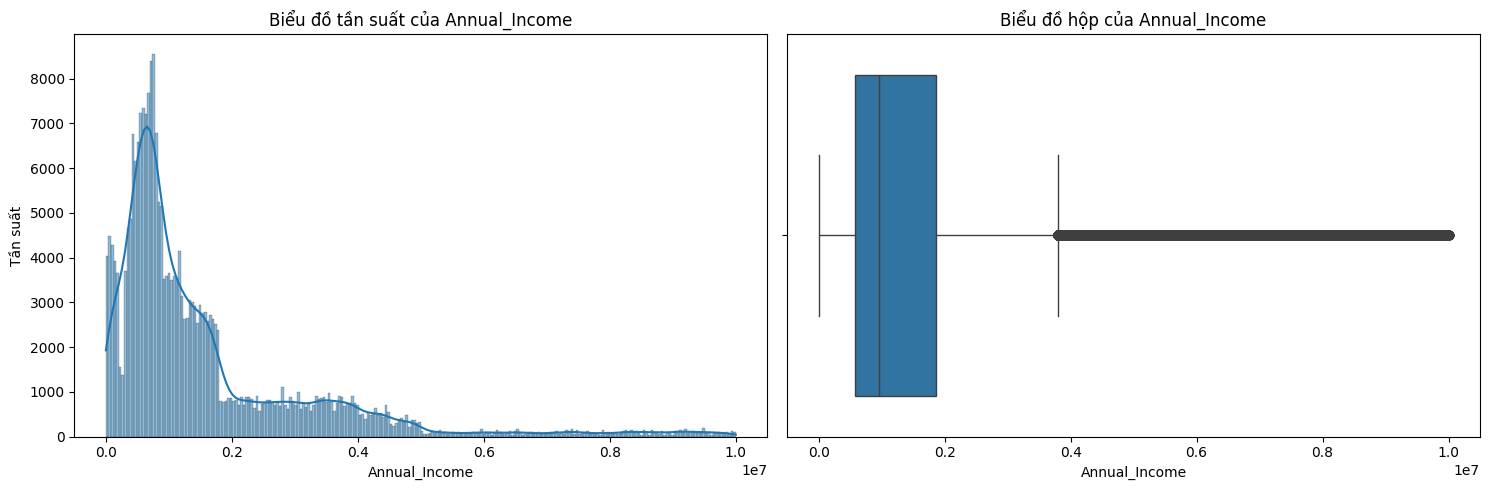

Độ lệch của 'Annual_Income': 2.29
Cột 'Annual_Income' bị lệch phải mạnh (độ lệch = 2.29). Có thể cân nhắc log-transform.


--- Phân phối của cột 'Credit_Limit' ---
count    2.500000e+05
mean     4.435445e+05
std      3.686547e+05
min      5.000200e+04
25%      1.614910e+05
50%      2.965890e+05
75%      6.157200e+05
max      1.499927e+06
Name: Credit_Limit, dtype: float64


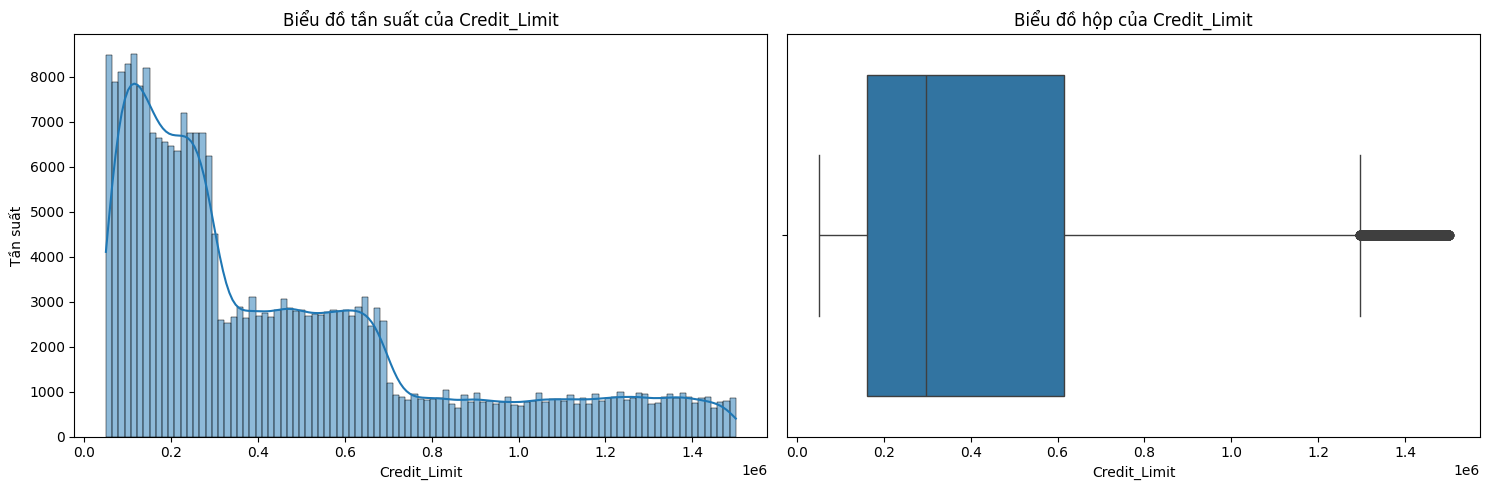

Độ lệch của 'Credit_Limit': 1.20
Cột 'Credit_Limit' bị lệch phải mạnh (độ lệch = 1.20). Có thể cân nhắc log-transform.




In [214]:
def plot_distribution_and_check_skew(df, column):
    print(f"--- Phân phối của cột '{column}' ---")
    print(df[column].describe())

    plt.figure(figsize=(15, 5))

    # Biểu đồ tần suất
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Biểu đồ tần suất của {column}')
    plt.xlabel(column)
    plt.ylabel('Tần suất')

    # Biểu đồ hộp
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[column])
    plt.title(f'Biểu đồ hộp của {column}')
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

    skewness = df[column].skew()
    print(f"Độ lệch của '{column}': {skewness:.2f}")
    if skewness > 1: # Ngưỡng thường dùng cho lệch phải mạnh
        print(f"Cột '{column}' bị lệch phải mạnh (độ lệch = {skewness:.2f}). Có thể cân nhắc log-transform.")
    elif skewness < -1: # Ngưỡng thường dùng cho lệch trái mạnh
        print(f"Cột '{column}' bị lệch trái mạnh (độ lệch = {skewness:.2f}). Có thể cân nhắc log-transform.")
    else:
        print(f"Cột '{column}' có phân phối tương đối đối xứng (độ lệch = {skewness:.2f}).")
    print("\n")

# Kiểm tra Annual_Income
plot_distribution_and_check_skew(df_merged, 'Annual_Income')

# Kiểm tra Credit_Limit
plot_distribution_and_check_skew(df_merged, 'Credit_Limit')

##`Age`: Kiểm tra khoảng hợp lý

--- Kiểm tra khoảng tuổi ---
Tuổi nhỏ nhất: 18
Tuổi lớn nhất: 70
Tất cả các giá trị tuổi đều nằm trong khoảng hợp lý (18-70).


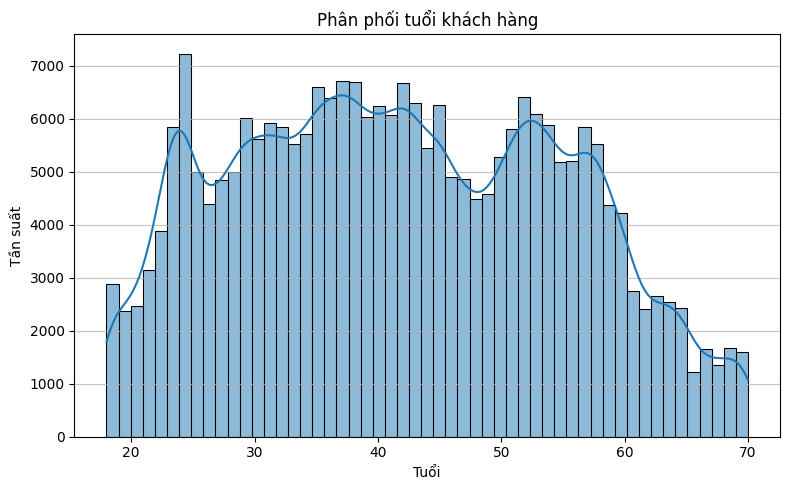

In [215]:
min_age = df_merged['Age'].min()
max_age = df_merged['Age'].max()

print(f"--- Kiểm tra khoảng tuổi ---")
print(f"Tuổi nhỏ nhất: {min_age}")
print(f"Tuổi lớn nhất: {max_age}")

if min_age >= 18 and max_age <= 70:
    print("Tất cả các giá trị tuổi đều nằm trong khoảng hợp lý (18-70).")
else:
    print("CÓ giá trị tuổi nằm ngoài khoảng hợp lý (18-70). Cần xem xét thêm.")

# Hiển thị phân phối tuổi để xác nhận
plt.figure(figsize=(8, 5))
sns.histplot(df_merged['Age'], bins=df_merged['Age'].nunique(), kde=True)
plt.title('Phân phối tuổi khách hàng')
plt.xlabel('Tuổi')
plt.ylabel('Tần suất')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

##Áp dụng Log-Transform cho `Annual_Income` và `Credit_Limit`

Đang áp dụng log-transform cho 'Annual_Income' và 'Credit_Limit'...
Log-transform đã hoàn tất. Hiển thị phân phối mới:
--- Phân phối của cột 'Annual_Income_log' ---
count    250000.000000
mean         13.775272
std           1.142473
min           1.098612
25%          13.253755
50%          13.777917
75%          14.436771
max          16.118089
Name: Annual_Income_log, dtype: float64


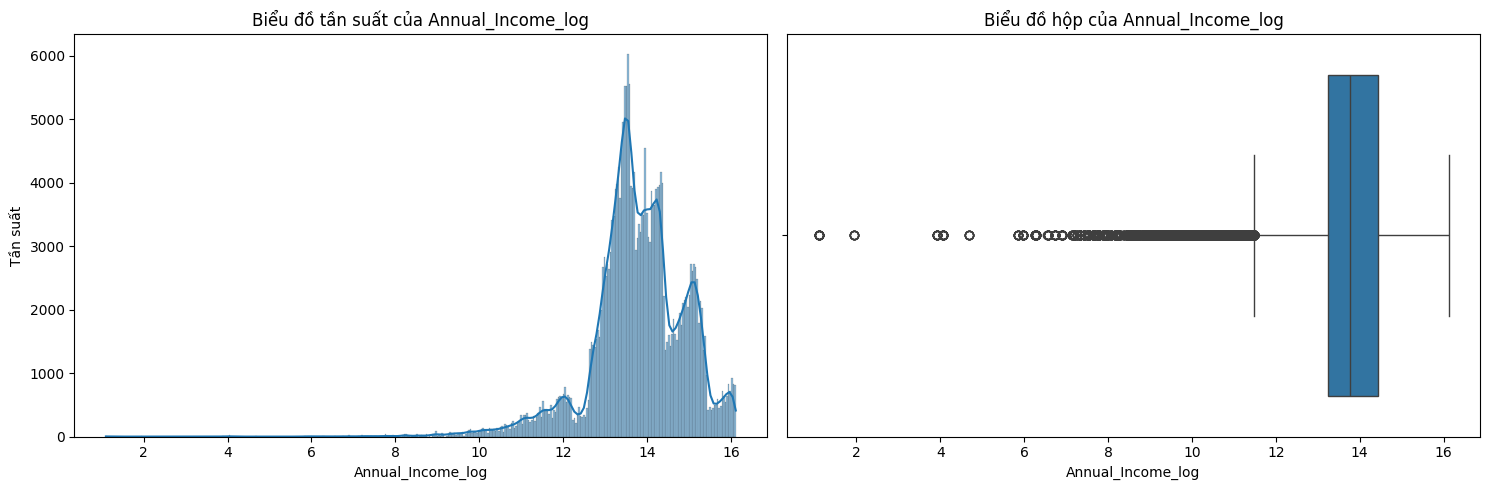

Độ lệch của 'Annual_Income_log': -1.14
Cột 'Annual_Income_log' bị lệch trái mạnh (độ lệch = -1.14). Có thể cân nhắc log-transform.


--- Phân phối của cột 'Credit_Limit_log' ---
count    250000.000000
mean         12.650448
std           0.870193
min          10.819838
25%          11.992211
50%          12.600106
75%          13.330549
max          14.220928
Name: Credit_Limit_log, dtype: float64


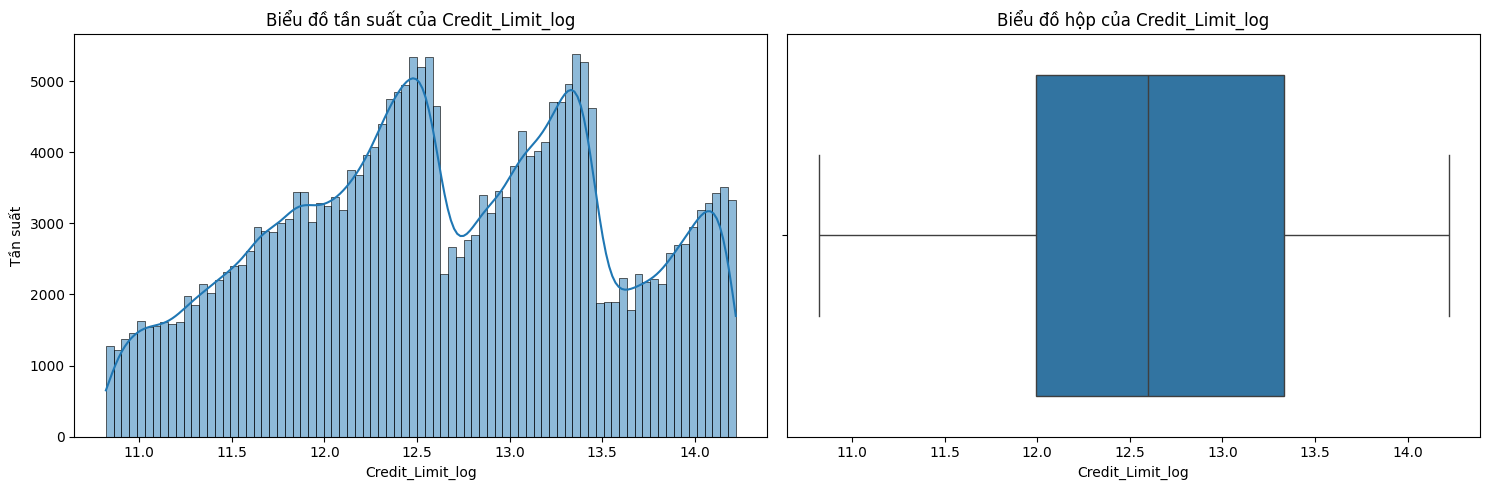

Độ lệch của 'Credit_Limit_log': -0.08
Cột 'Credit_Limit_log' có phân phối tương đối đối xứng (độ lệch = -0.08).




In [216]:
print("Đang áp dụng log-transform cho 'Annual_Income' và 'Credit_Limit'...")

# Áp dụng log-transform cho Annual_Income (sử dụng np.log1p để xử lý giá trị 0 an toàn, mặc dù min > 0)
df_merged['Annual_Income_log'] = np.log1p(df_merged['Annual_Income'])

# Áp dụng log-transform cho Credit_Limit
df_merged['Credit_Limit_log'] = np.log1p(df_merged['Credit_Limit'])

print("Log-transform đã hoàn tất. Hiển thị phân phối mới:")

# Kiểm tra phân phối sau log-transform
plot_distribution_and_check_skew(df_merged, 'Annual_Income_log')
plot_distribution_and_check_skew(df_merged, 'Credit_Limit_log')

## Áp dụng Log-Transform cho `Annual_Income` và `Credit_Limit`

Đang áp dụng log-transform cho 'Annual_Income' và 'Credit_Limit'...
Log-transform đã hoàn tất. Hiển thị phân phối mới:
--- Phân phối của cột 'Annual_Income_log' ---
count    250000.000000
mean         13.775272
std           1.142473
min           1.098612
25%          13.253755
50%          13.777917
75%          14.436771
max          16.118089
Name: Annual_Income_log, dtype: float64


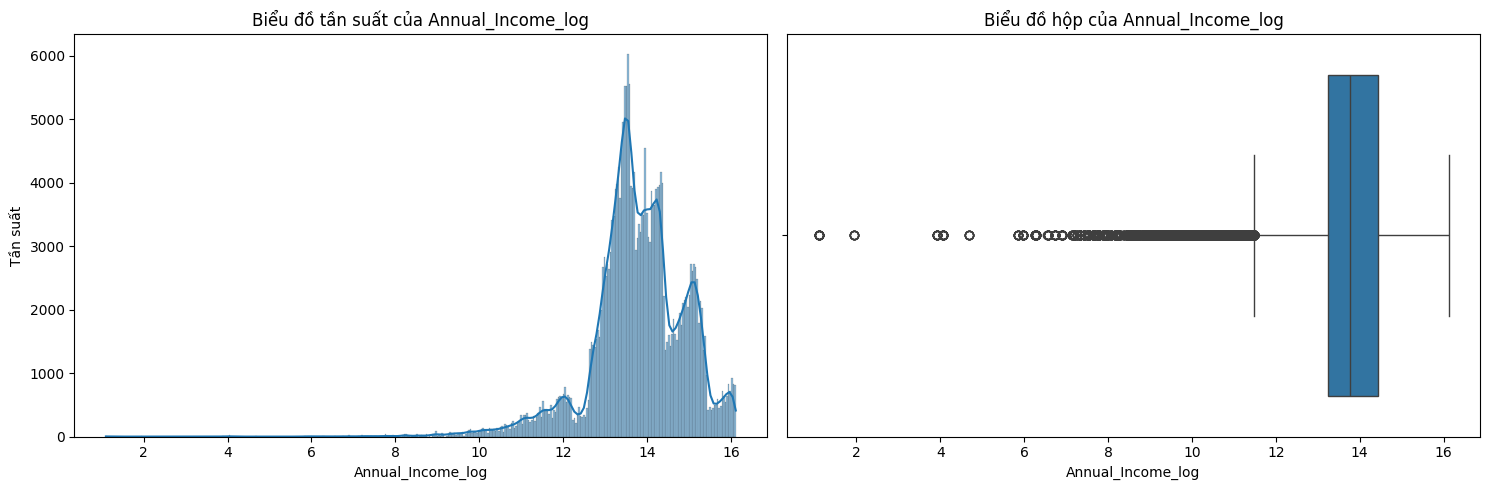

Độ lệch của 'Annual_Income_log': -1.14
Cột 'Annual_Income_log' bị lệch trái mạnh (độ lệch = -1.14). Có thể cân nhắc log-transform.


--- Phân phối của cột 'Credit_Limit_log' ---
count    250000.000000
mean         12.650448
std           0.870193
min          10.819838
25%          11.992211
50%          12.600106
75%          13.330549
max          14.220928
Name: Credit_Limit_log, dtype: float64


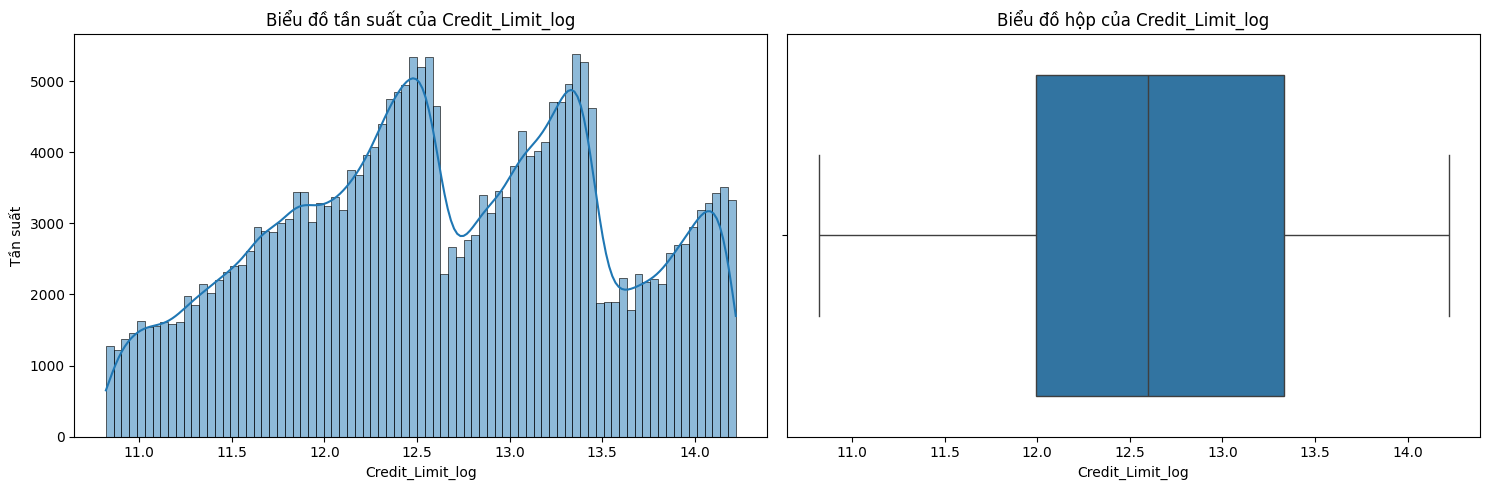

Độ lệch của 'Credit_Limit_log': -0.08
Cột 'Credit_Limit_log' có phân phối tương đối đối xứng (độ lệch = -0.08).




In [217]:
print("Đang áp dụng log-transform cho 'Annual_Income' và 'Credit_Limit'...")

# Áp dụng log-transform cho Annual_Income (sử dụng np.log1p để xử lý giá trị 0 an toàn, mặc dù min > 0)
df_merged['Annual_Income_log'] = np.log1p(df_merged['Annual_Income'])

# Áp dụng log-transform cho Credit_Limit
df_merged['Credit_Limit_log'] = np.log1p(df_merged['Credit_Limit'])

print("Log-transform đã hoàn tất. Hiển thị phân phối mới:")

# Kiểm tra phân phối sau log-transform
plot_distribution_and_check_skew(df_merged, 'Annual_Income_log')
plot_distribution_and_check_skew(df_merged, 'Credit_Limit_log')

#Xử lý ngoại lai (Outlier Treatment) & Kiểm tra phân phối dữ liệu

##`Transaction_Amount`: Phát hiện giao dịch bất thường lớn

--- Phát hiện ngoại lệ cho cột 'Transaction_Amount' bằng phương pháp IQR ---
Q1 (25th percentile): 1,000.00
Q3 (75th percentile): 18,309.91
IQR: 17,309.91
Giới hạn dưới: -24,964.86
Giới hạn trên: 44,274.77
Số lượng ngoại lệ được phát hiện: 24,641
Tỷ lệ ngoại lệ: 9.86%
Dưới đây là 5 ngoại lệ đầu tiên (hoặc tất cả nếu ít hơn 5):


,Transaction_ID,Customer_ID,Card_ID,Merchant_ID,Transaction_Date,Transaction_Time,Transaction_Amount,Payment_Method,Transaction_Channel,Device_Type,...,Contactless,Card_Mode,Issue_Date,Expiry_Date,Merchant_Name,Merchant_Rating,Merchant_Status,Merchant_Since,Annual_Income_log,Credit_Limit_log
3,TXN1000004,CUST109049,CARD511773,MER100053,2023-05-25,01:48:56,52694.99,Credit Card,POS,POS Terminal,...,Yes,Physical,2020-10-31,2025-10-31,PhonePe,4.4,Active,2011-06-25,14.907430,14.160341
6,TXN1000007,CUST117124,CARD522230,MER100428,2025-10-05,17:55:46,83430.87,Debit Card,ATM,ATM Machine,...,Yes,Physical,2024-03-18,2029-03-18,Coursera,3.5,Active,2023-01-03,10.292078,11.101885
7,TXN1000008,CUST117464,CARD522663,MER100037,2025-08-04,06:02:59,47447.47,Debit Card,ATM,ATM Machine,...,Yes,Physical,2022-03-02,2027-03-02,SpiceJet,4.0,Active,2011-07-11,15.043185,12.471950
20,TXN1000021,CUST115845,CARD520588,MER100284,2026-01-22,08:49:29,253850.67,UPI,Mobile App,Android Mobile,...,Yes,Physical,2025-10-25,2030-10-25,Jio-bp,4.2,Active,2022-06-24,13.255833,12.576988
32,TXN1000033,CUST101949,CARD502535,MER100005,2023-12-22,23:03:40,79179.14,UPI,Mobile App,Android Mobile,...,Yes,Physical,2019-06-30,2024-06-30,IndiGo,4.1,Active,2007-07-18,12.072781,11.828561


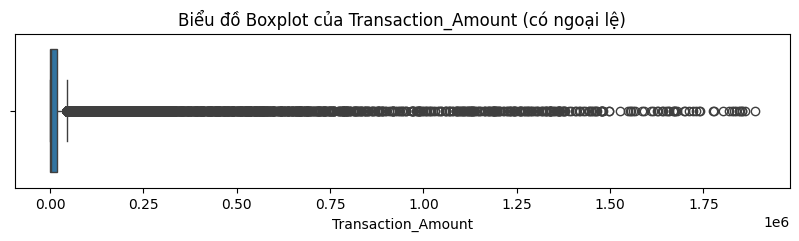

In [218]:
def display_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"--- Phát hiện ngoại lệ cho cột '{column}' bằng phương pháp IQR ---")
    print(f"Q1 (25th percentile): {Q1:,.2f}")
    print(f"Q3 (75th percentile): {Q3:,.2f}")
    print(f"IQR: {IQR:,.2f}")
    print(f"Giới hạn dưới: {lower_bound:,.2f}")
    print(f"Giới hạn trên: {upper_bound:,.2f}")
    print(f"Số lượng ngoại lệ được phát hiện: {len(outliers):,}")
    print(f"Tỷ lệ ngoại lệ: {len(outliers) / len(df) * 100:.2f}%")

    if not outliers.empty:
        print("Dưới đây là 5 ngoại lệ đầu tiên (hoặc tất cả nếu ít hơn 5):")
        display(outliers.head())
    else:
        print("Không tìm thấy ngoại lệ nào.")

    plt.figure(figsize=(10, 2))
    sns.boxplot(x=df[column])
    plt.title(f"Biểu đồ Boxplot của {column} (có ngoại lệ)")
    plt.show()

display_outliers_iqr(df_merged, 'Transaction_Amount')

##`Annual_Income` và `Credit_Limit`: Kiểm tra phân phối và log-transform nếu lệch phải

--- Phân phối của cột 'Annual_Income' ---
count    2.500000e+05
mean     1.608372e+06
std      1.732134e+06
min      2.000000e+00
25%      5.702060e+05
50%      9.631030e+05
75%      1.861271e+06
max      9.999931e+06
Name: Annual_Income, dtype: float64


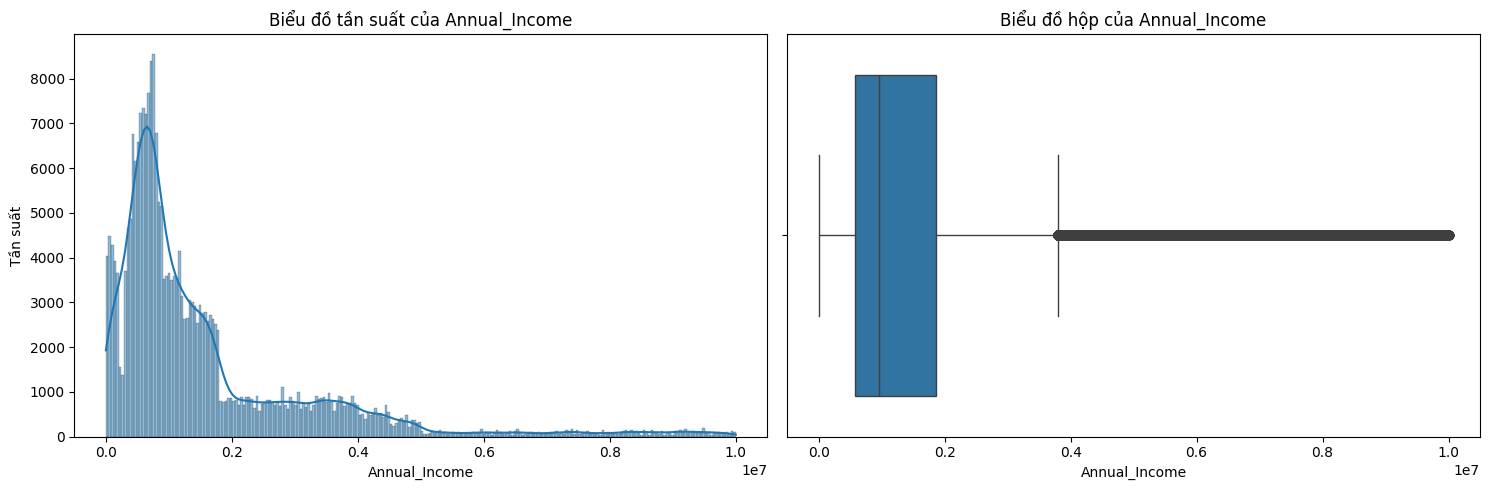

Độ lệch của 'Annual_Income': 2.29
Cột 'Annual_Income' bị lệch phải mạnh (độ lệch = 2.29). Có thể cân nhắc log-transform.


--- Phân phối của cột 'Credit_Limit' ---
count    2.500000e+05
mean     4.435445e+05
std      3.686547e+05
min      5.000200e+04
25%      1.614910e+05
50%      2.965890e+05
75%      6.157200e+05
max      1.499927e+06
Name: Credit_Limit, dtype: float64


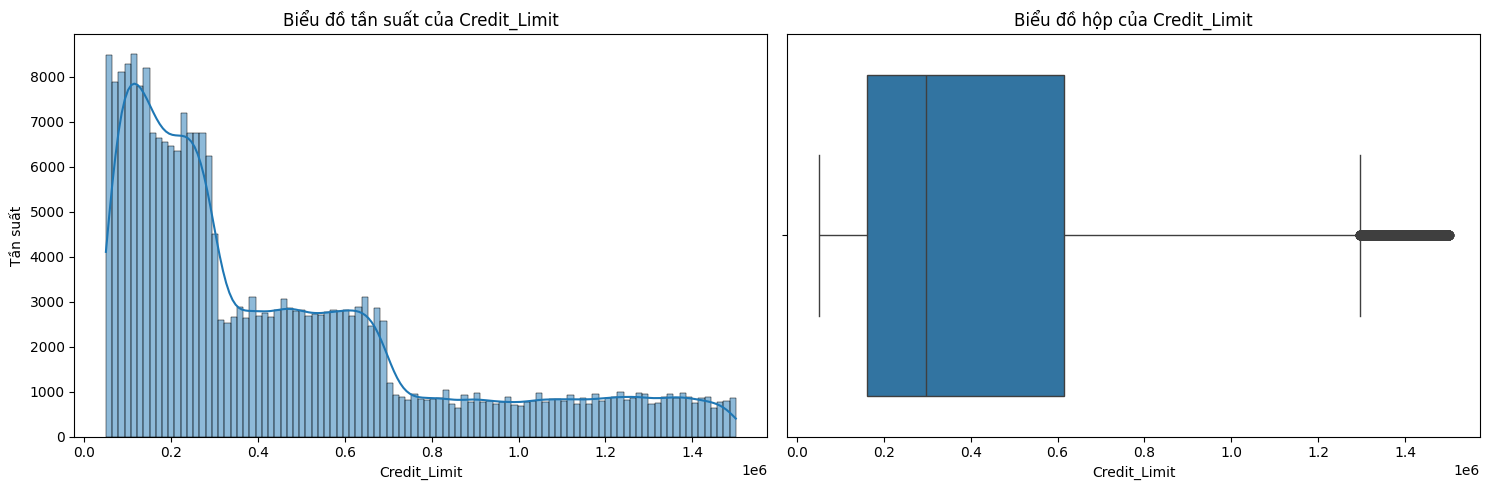

Độ lệch của 'Credit_Limit': 1.20
Cột 'Credit_Limit' bị lệch phải mạnh (độ lệch = 1.20). Có thể cân nhắc log-transform.




In [219]:
def plot_distribution_and_check_skew(df, column):
    print(f"--- Phân phối của cột '{column}' ---")
    print(df[column].describe())

    plt.figure(figsize=(15, 5))

    # Biểu đồ tần suất
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Biểu đồ tần suất của {column}')
    plt.xlabel(column)
    plt.ylabel('Tần suất')

    # Biểu đồ hộp
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[column])
    plt.title(f'Biểu đồ hộp của {column}')
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

    skewness = df[column].skew()
    print(f"Độ lệch của '{column}': {skewness:.2f}")
    if skewness > 1: # Ngưỡng thường dùng cho lệch phải mạnh
        print(f"Cột '{column}' bị lệch phải mạnh (độ lệch = {skewness:.2f}). Có thể cân nhắc log-transform.")
    elif skewness < -1: # Ngưỡng thường dùng cho lệch trái mạnh
        print(f"Cột '{column}' bị lệch trái mạnh (độ lệch = {skewness:.2f}). Có thể cân nhắc log-transform.")
    else:
        print(f"Cột '{column}' có phân phối tương đối đối xứng (độ lệch = {skewness:.2f}).")
    print("\n")

# Kiểm tra Annual_Income
plot_distribution_and_check_skew(df_merged, 'Annual_Income')

# Kiểm tra Credit_Limit
plot_distribution_and_check_skew(df_merged, 'Credit_Limit')

##`Age`: Kiểm tra khoảng hợp lý

--- Kiểm tra khoảng tuổi ---
Tuổi nhỏ nhất: 18
Tuổi lớn nhất: 70
Tất cả các giá trị tuổi đều nằm trong khoảng hợp lý (18-70).


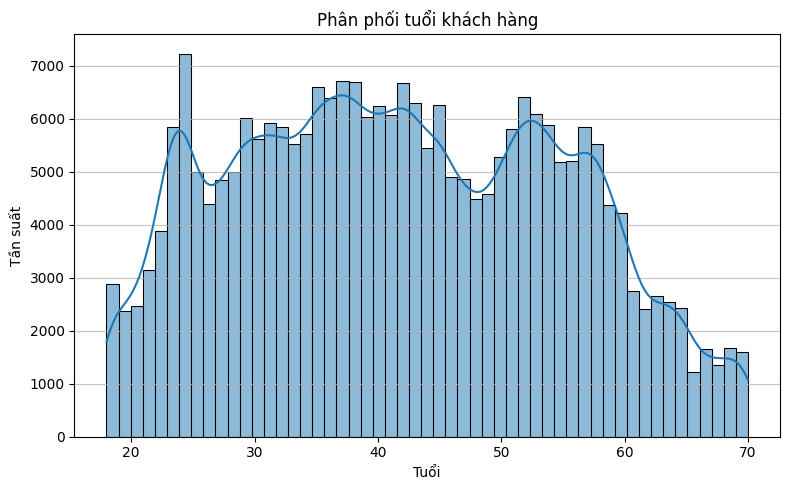

In [220]:
min_age = df_merged['Age'].min()
max_age = df_merged['Age'].max()

print(f"--- Kiểm tra khoảng tuổi ---")
print(f"Tuổi nhỏ nhất: {min_age}")
print(f"Tuổi lớn nhất: {max_age}")

if min_age >= 18 and max_age <= 70:
    print("Tất cả các giá trị tuổi đều nằm trong khoảng hợp lý (18-70).")
else:
    print("CÓ giá trị tuổi nằm ngoài khoảng hợp lý (18-70). Cần xem xét thêm.")

# Hiển thị phân phối tuổi để xác nhận
plt.figure(figsize=(8, 5))
sns.histplot(df_merged['Age'], bins=df_merged['Age'].nunique(), kde=True)
plt.title('Phân phối tuổi khách hàng')
plt.xlabel('Tuổi')
plt.ylabel('Tần suất')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

##Áp dụng Log-Transform cho `Annual_Income` và `Credit_Limit`

Đang áp dụng log-transform cho 'Annual_Income' và 'Credit_Limit'...
Log-transform đã hoàn tất. Hiển thị phân phối mới:
--- Phân phối của cột 'Annual_Income_log' ---
count    250000.000000
mean         13.775272
std           1.142473
min           1.098612
25%          13.253755
50%          13.777917
75%          14.436771
max          16.118089
Name: Annual_Income_log, dtype: float64


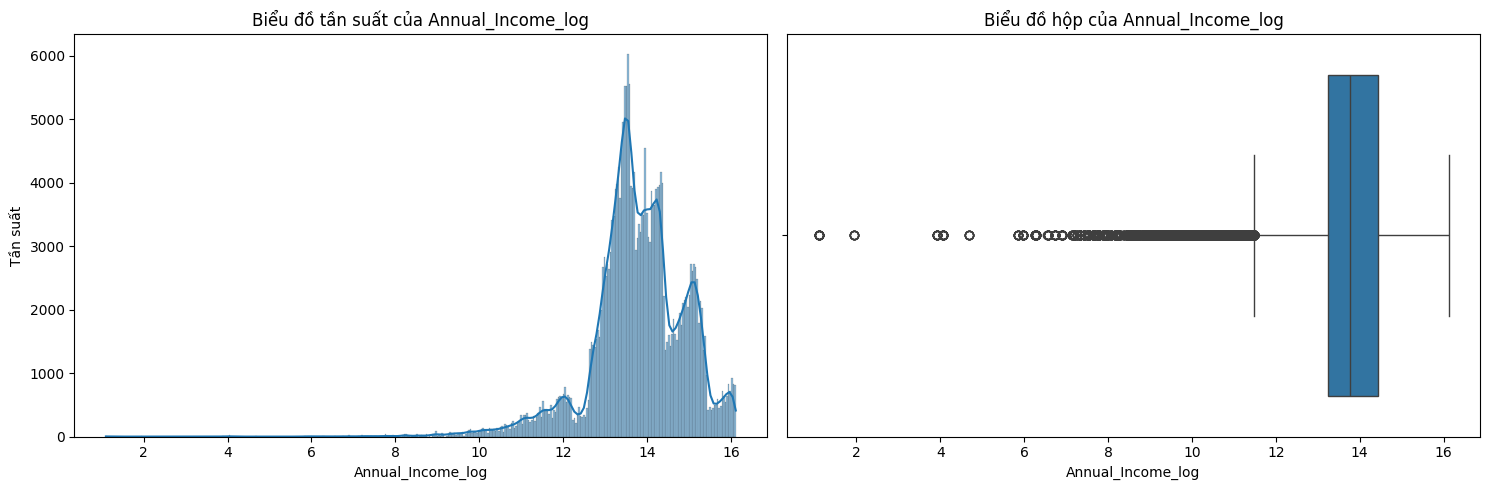

Độ lệch của 'Annual_Income_log': -1.14
Cột 'Annual_Income_log' bị lệch trái mạnh (độ lệch = -1.14). Có thể cân nhắc log-transform.


--- Phân phối của cột 'Credit_Limit_log' ---
count    250000.000000
mean         12.650448
std           0.870193
min          10.819838
25%          11.992211
50%          12.600106
75%          13.330549
max          14.220928
Name: Credit_Limit_log, dtype: float64


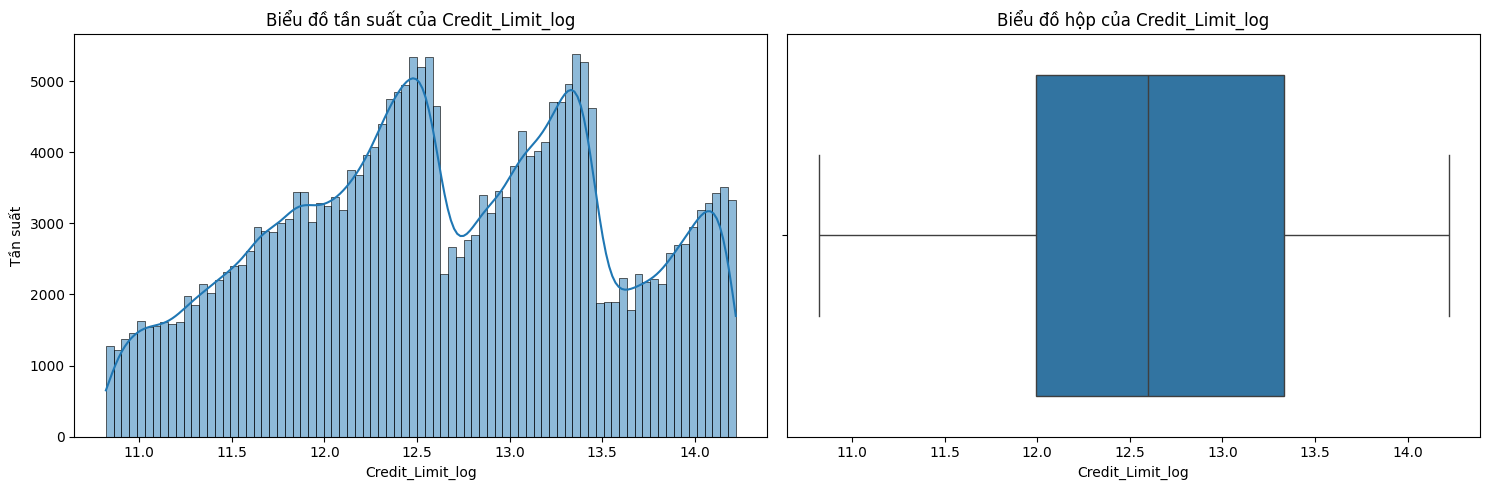

Độ lệch của 'Credit_Limit_log': -0.08
Cột 'Credit_Limit_log' có phân phối tương đối đối xứng (độ lệch = -0.08).




In [221]:
print("Đang áp dụng log-transform cho 'Annual_Income' và 'Credit_Limit'...")

# Áp dụng log-transform cho Annual_Income (sử dụng np.log1p để xử lý giá trị 0 an toàn, mặc dù min > 0)
df_merged['Annual_Income_log'] = np.log1p(df_merged['Annual_Income'])

# Áp dụng log-transform cho Credit_Limit
df_merged['Credit_Limit_log'] = np.log1p(df_merged['Credit_Limit'])

print("Log-transform đã hoàn tất. Hiển thị phân phối mới:")

# Kiểm tra phân phối sau log-transform
plot_distribution_and_check_skew(df_merged, 'Annual_Income_log')
plot_distribution_and_check_skew(df_merged, 'Credit_Limit_log')

## Áp dụng Log-Transform cho `Annual_Income` và `Credit_Limit`

Đang áp dụng log-transform cho 'Annual_Income' và 'Credit_Limit'...
Log-transform đã hoàn tất. Hiển thị phân phối mới:
--- Phân phối của cột 'Annual_Income_log' ---
count    250000.000000
mean         13.775272
std           1.142473
min           1.098612
25%          13.253755
50%          13.777917
75%          14.436771
max          16.118089
Name: Annual_Income_log, dtype: float64


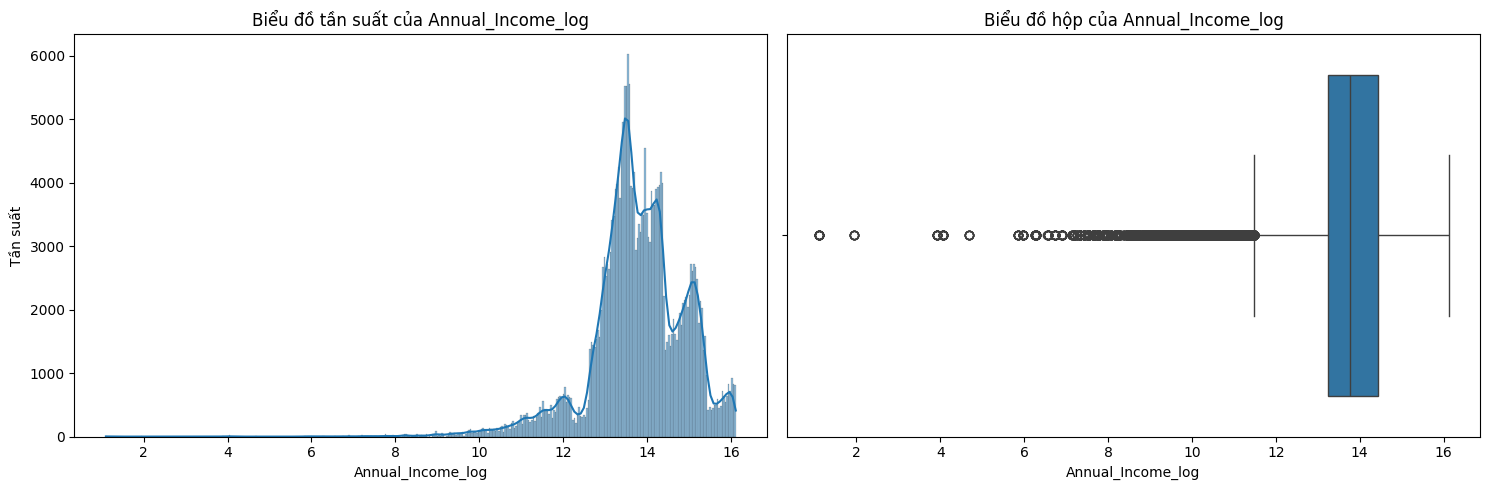

Độ lệch của 'Annual_Income_log': -1.14
Cột 'Annual_Income_log' bị lệch trái mạnh (độ lệch = -1.14). Có thể cân nhắc log-transform.


--- Phân phối của cột 'Credit_Limit_log' ---
count    250000.000000
mean         12.650448
std           0.870193
min          10.819838
25%          11.992211
50%          12.600106
75%          13.330549
max          14.220928
Name: Credit_Limit_log, dtype: float64


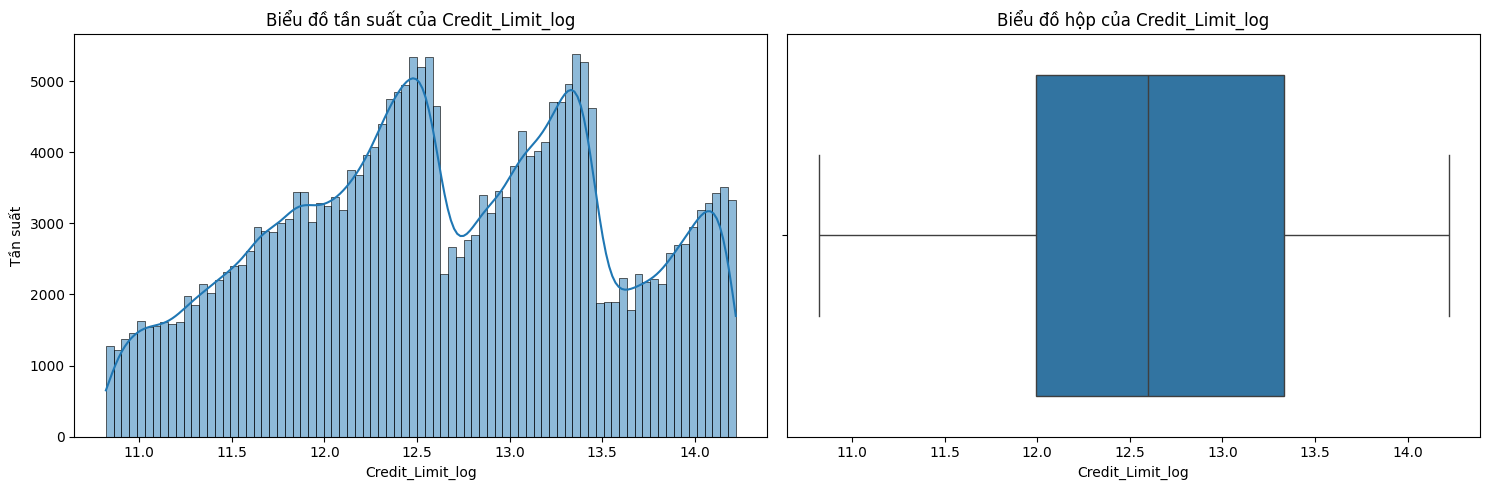

Độ lệch của 'Credit_Limit_log': -0.08
Cột 'Credit_Limit_log' có phân phối tương đối đối xứng (độ lệch = -0.08).




In [222]:
print("Đang áp dụng log-transform cho 'Annual_Income' và 'Credit_Limit'...")

# Áp dụng log-transform cho Annual_Income (sử dụng np.log1p để xử lý giá trị 0 an toàn, mặc dù min > 0)
df_merged['Annual_Income_log'] = np.log1p(df_merged['Annual_Income'])

# Áp dụng log-transform cho Credit_Limit
df_merged['Credit_Limit_log'] = np.log1p(df_merged['Credit_Limit'])

print("Log-transform đã hoàn tất. Hiển thị phân phối mới:")

# Kiểm tra phân phối sau log-transform
plot_distribution_and_check_skew(df_merged, 'Annual_Income_log')
plot_distribution_and_check_skew(df_merged, 'Credit_Limit_log')

# Trực quan hoá (Visualization)

## Phương thức thanh toán

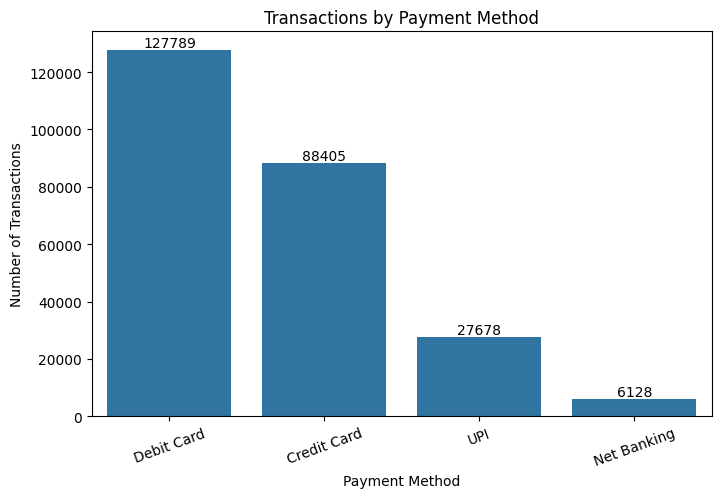

In [223]:
payment = df_merged["Payment_Method"].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=payment.index,
    y=payment.values
)

plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

for i in ax.containers:
    ax.bar_label(i, fmt='%d')

plt.xticks(rotation=20)

plt.show()

## Kênh giao dịch

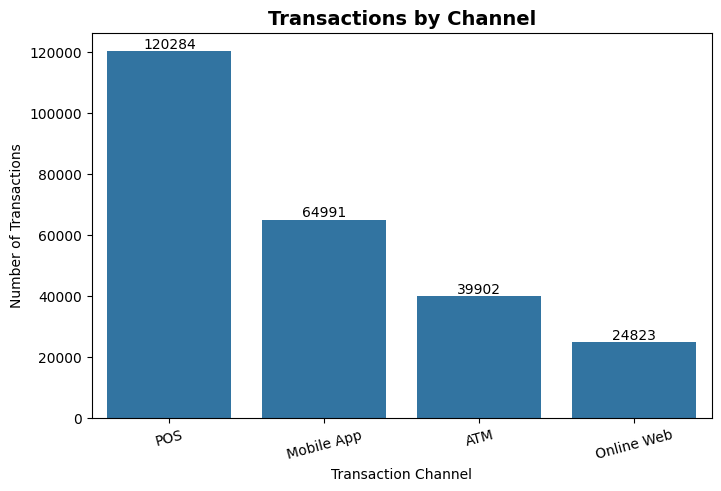

In [224]:
channel = df_merged["Transaction_Channel"].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=channel.index,
    y=channel.values
)

plt.title("Transactions by Channel", fontsize=14, weight="bold")
plt.xlabel("Transaction Channel")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.xticks(rotation=15)

plt.show()

## Phân bổ danh mục Merchant

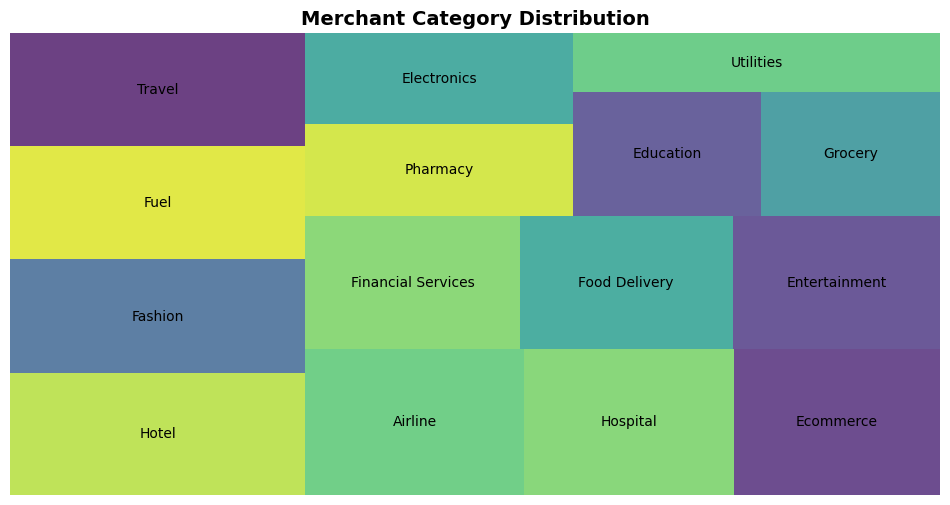

In [225]:
merchant = df_merged["Merchant_Category"].value_counts()

plt.figure(figsize=(12,6))

squarify.plot(
    sizes=merchant.values,
    label=merchant.index,
    alpha=0.8
)

plt.title("Merchant Category Distribution", fontsize=14, weight="bold")

plt.axis("off")

plt.show()

## Loại thiết bị

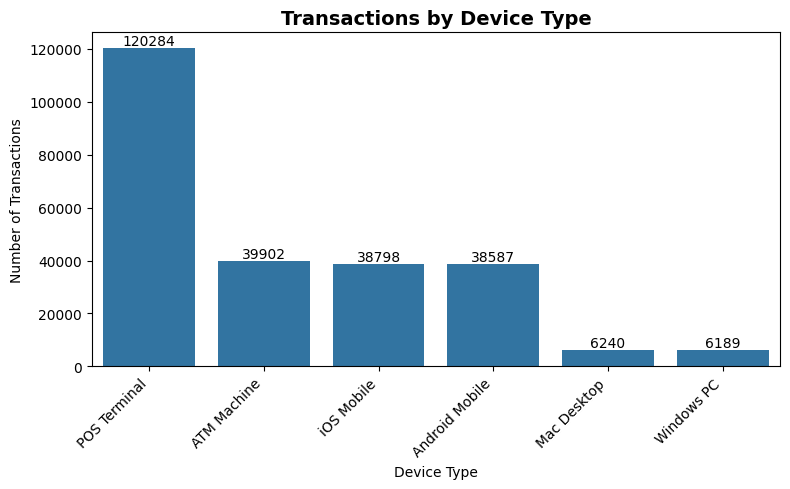

In [226]:
device = df_merged["Device_Type"].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=device.index,
    y=device.values
)

plt.title("Transactions by Device Type", fontsize=14, weight="bold")
plt.xlabel("Device Type")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

## Hạng thẻ

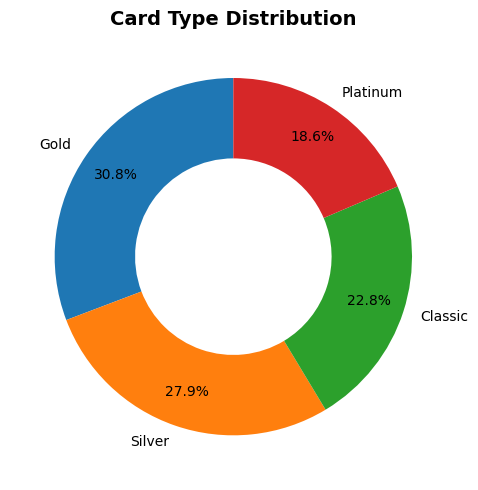

In [227]:
card = df_merged["Card_Type"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    card.values,
    labels=card.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.45},
    pctdistance=0.8
)

plt.title("Card Type Distribution", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

## Mạng lưới thẻ

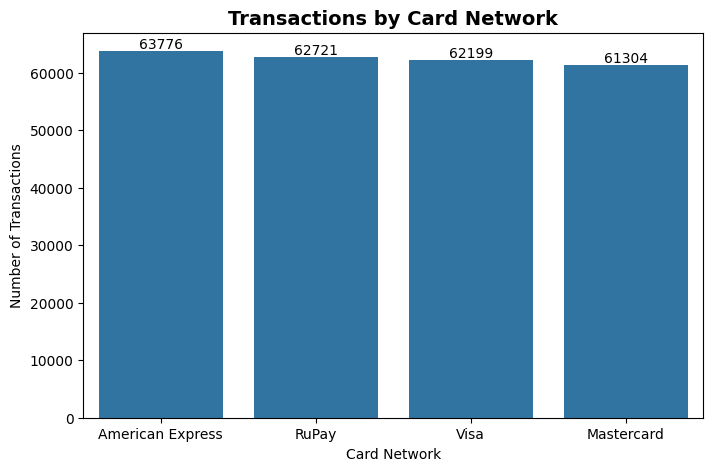

In [228]:
network = df_merged["Card_Network"].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=network.index,
    y=network.values
)

plt.title("Transactions by Card Network", fontsize=14, weight="bold")
plt.xlabel("Card Network")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

## Trang thái giao dịch

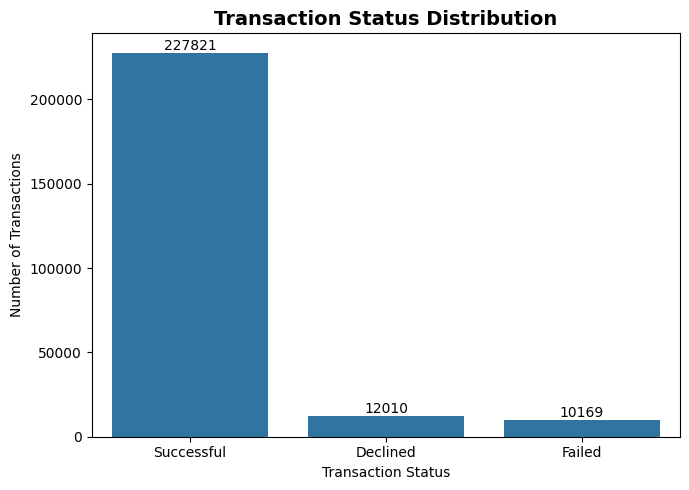

In [229]:
status = df_merged["Transaction_Status"].value_counts()

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=status.index,
    y=status.values
)

plt.title("Transaction Status Distribution", fontsize=14, weight="bold")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

## Giới tính

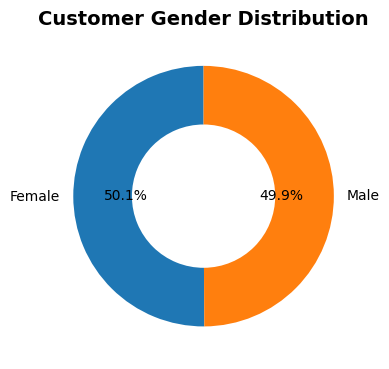

In [230]:
gender = df_merged["Gender"].value_counts()

plt.figure(figsize=(4,4))

plt.pie(
    gender.values,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.45}
)

plt.title("Customer Gender Distribution", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

## Độ tuổi

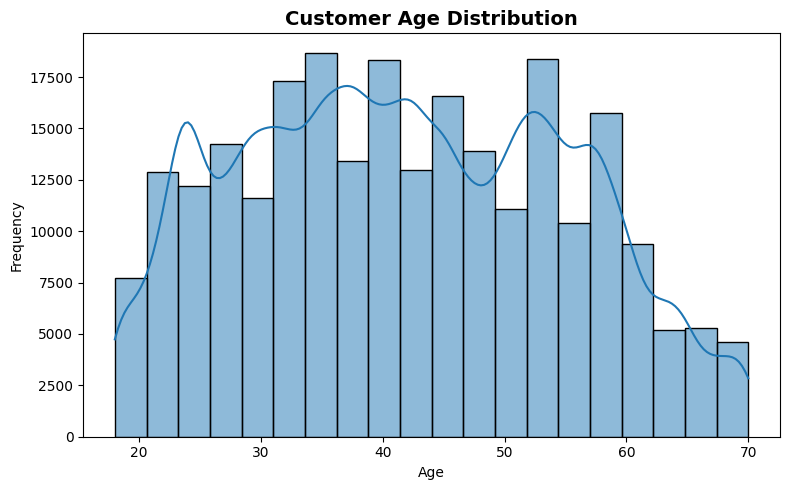

In [231]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_merged["Age"],
    bins=20,
    kde=True
)

plt.title("Customer Age Distribution", fontsize=14, weight="bold")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Lượng giao dịch

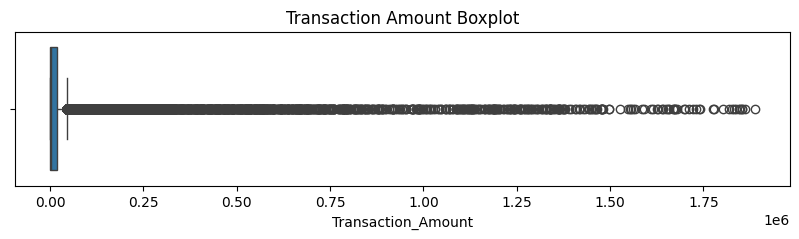

In [232]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df_merged["Transaction_Amount"]
)

plt.title("Transaction Amount Boxplot")

plt.show()

## Phân khúc khách hàng

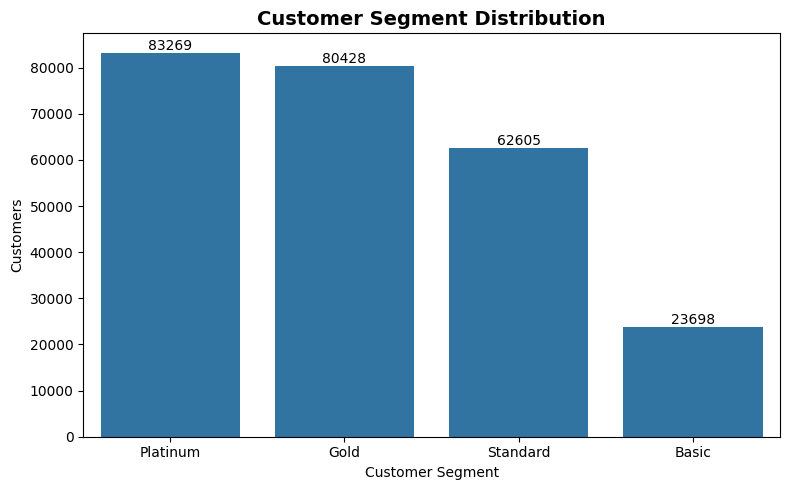

In [233]:
segment = df_merged["Customer_Segment"].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=segment.index,
    y=segment.values
)

plt.title("Customer Segment Distribution", fontsize=14, weight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Customers")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()


## Ngày giao dịch

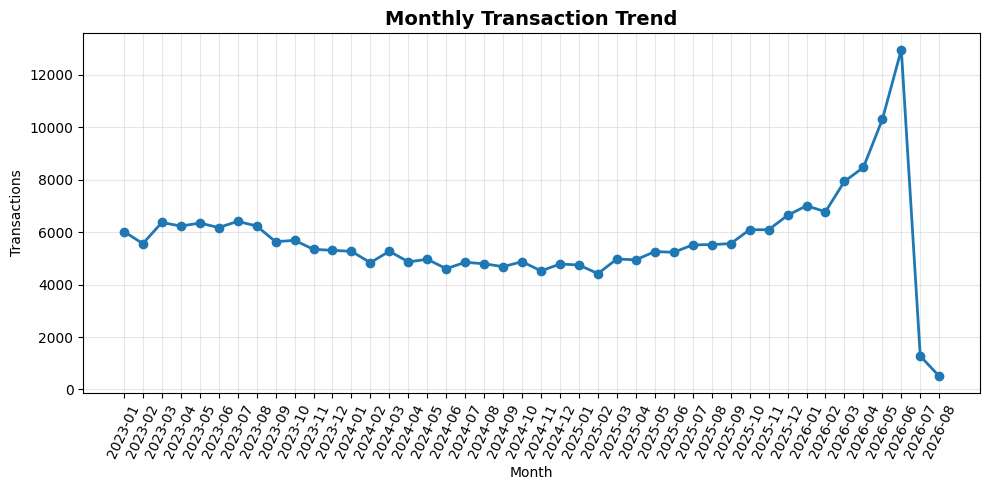

In [234]:
monthly = (
  df_merged
  .groupby(df_merged["Transaction_Date"].dt.to_period("M"))
  .size()
)

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Transaction Trend", fontsize=14, weight="bold")
plt.xlabel("Month")
plt.ylabel("Transactions")

plt.xticks(rotation=65)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Thu nhập hàng năm

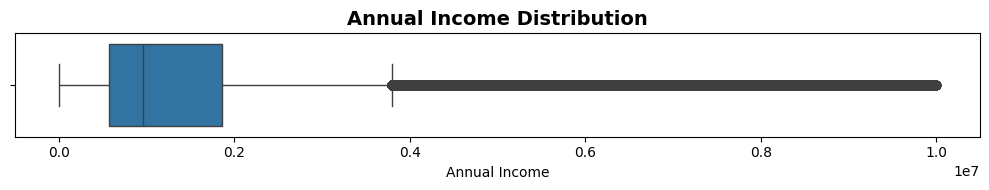

In [235]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df_merged["Annual_Income"]
)

plt.title("Annual Income Distribution", fontsize=14, weight="bold")
plt.xlabel("Annual Income")

plt.tight_layout()
plt.show()

Hãy cùng kiểm tra các hàng có `Annual_Income` bất thường (ví dụ: dưới 1.000) để xem liệu chúng có phải là lỗi nhập liệu hay không.

In [236]:
low_income_records = c_orig[c_orig['Annual_Income'] < 1000]
display(low_income_records)

,Customer_ID,Customer_Name,Gender,Age,Marital_Status,Occupation,Annual_Income,Customer_Segment,State,City,Account_Type,Customer_Since
735,CUST100736,Leena Ghosh,Female,23,Single,Student,107,Basic,Punjab,Jalandhar,Student,2020-07-26
2728,CUST102729,Anvi Agarwal,Female,18,Single,Student,57,Basic,Haryana,Faridabad,Student,2026-06-22
3132,CUST103133,Ikshita Bahl,Male,23,Single,Student,998,Basic,Maharashtra,Nagpur,Student,2025-11-25
3619,CUST103620,Banjeet Nigam,Female,18,Single,Student,540,Basic,Uttar Pradesh,Aligarh,Student,2022-10-27
6885,CUST106886,Ojas Sarraf,Female,23,Single,Student,2,Basic,Tamil Nadu,Tiruchirappalli,Student,2016-11-11
8033,CUST108034,Mitesh Bhatt,Male,23,Single,Student,695,Basic,Gujarat,Jamnagar,Student,2023-04-14
9715,CUST109716,Harish Om,Female,21,Single,Student,838,Basic,Maharashtra,Nagpur,Student,2024-04-27
10755,CUST110756,Shivani Oommen,Female,22,Single,Student,518,Basic,Tamil Nadu,Salem,Student,2018-12-21
10853,CUST110854,Charles Shan,Female,18,Single,Student,49,Basic,Assam,Guwahati,Student,2017-03-16
11362,CUST111363,Reyansh Deo,Female,23,Single,Student,395,Basic,Bihar,Gaya,Student,2019-11-21


## Bản đồ nhiệt tương quan

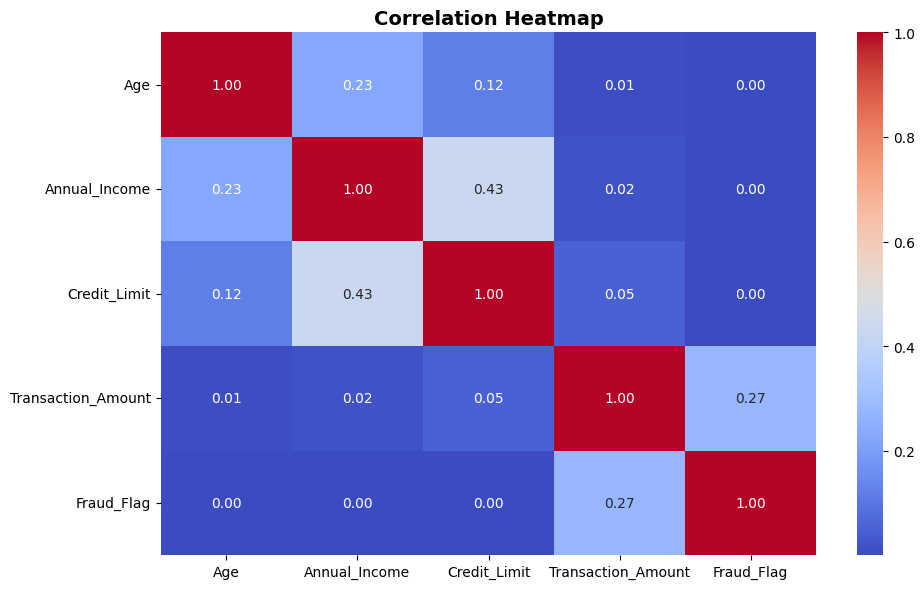

In [237]:
plt.figure(figsize=(10,6))

corr = df_merged[
    [
        "Age",
        "Annual_Income",
        "Credit_Limit",
        "Transaction_Amount",
        "Fraud_Flag"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

## Số tiền Giao dịch so với Hạn mức Tín dụng

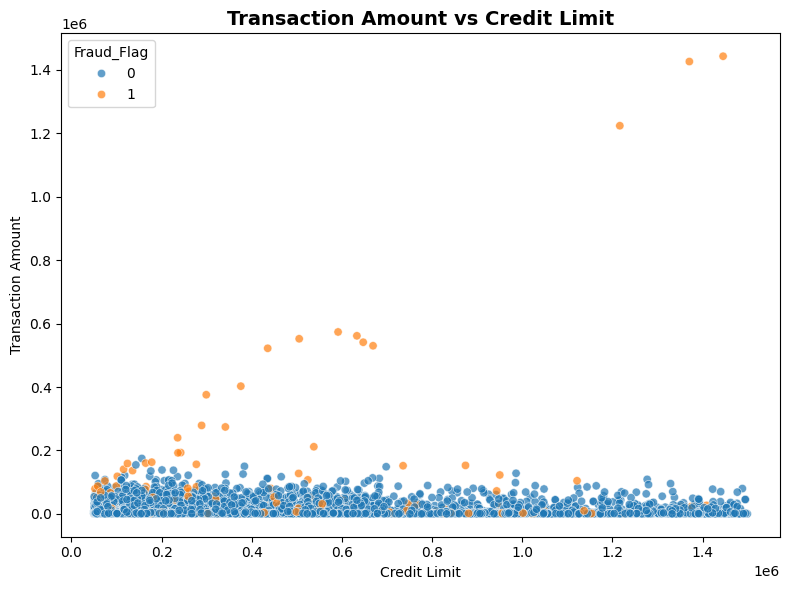

In [238]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_merged.sample(5000, random_state=42),
    x="Credit_Limit",
    y="Transaction_Amount",
    hue="Fraud_Flag",
    alpha=0.7
)

plt.title("Transaction Amount vs Credit Limit", fontsize=14, weight="bold")
plt.xlabel("Credit Limit")
plt.ylabel("Transaction Amount")

plt.tight_layout()
plt.show()

# Phòng tránh rò rỉ dữ liệu (Data Leakage)

## Loại bỏ `Fraud_Reason` khỏi tập feature train

In [239]:
df_merged = df_merged.drop('Fraud_Reason', axis=1)
print(df_merged.head())

  Transaction_ID Customer_ID     Card_ID Merchant_ID Transaction_Date  \
0     TXN1000001  CUST100660  CARD500875   MER100380       2024-03-03   
1     TXN1000002  CUST111388  CARD514772   MER100017       2023-11-08   
2     TXN1000003  CUST115872  CARD520625   MER100143       2023-01-11   
3     TXN1000004  CUST109049  CARD511773   MER100053       2023-05-25   
4     TXN1000005  CUST114459  CARD518771   MER100064       2023-10-22   

  Transaction_Time  Transaction_Amount Payment_Method Transaction_Channel  \
0         05:50:10            21748.02     Debit Card          Mobile App   
1         06:55:15             9960.60     Debit Card                 POS   
2         02:17:28              838.61     Debit Card                 ATM   
3         01:48:56            52694.99    Credit Card                 POS   
4         00:23:32             1043.40     Debit Card          Online Web   

      Device_Type  ... Contactless  Card_Mode  Issue_Date Expiry_Date  \
0  Android Mobile  ...   

## Loại bỏ Transaction_Status

In [240]:
print("Phân tích mối quan hệ giữa Transaction_Status và Fraud_Flag:")
display(df_merged.groupby(['Transaction_Status', 'Fraud_Flag']).size().unstack(fill_value=0)) # để cái này lại

Phân tích mối quan hệ giữa Transaction_Status và Fraud_Flag:


Fraud_Flag,0,1
Transaction_Status,,
Declined,4857,7153
Failed,6996,3173
Successful,224674,3147


In [241]:
df_merged = df_merged.drop('Transaction_Status', axis=1)
print(df_merged.head())

  Transaction_ID Customer_ID     Card_ID Merchant_ID Transaction_Date  \
0     TXN1000001  CUST100660  CARD500875   MER100380       2024-03-03   
1     TXN1000002  CUST111388  CARD514772   MER100017       2023-11-08   
2     TXN1000003  CUST115872  CARD520625   MER100143       2023-01-11   
3     TXN1000004  CUST109049  CARD511773   MER100053       2023-05-25   
4     TXN1000005  CUST114459  CARD518771   MER100064       2023-10-22   

  Transaction_Time  Transaction_Amount Payment_Method Transaction_Channel  \
0         05:50:10            21748.02     Debit Card          Mobile App   
1         06:55:15             9960.60     Debit Card                 POS   
2         02:17:28              838.61     Debit Card                 ATM   
3         01:48:56            52694.99    Credit Card                 POS   
4         00:23:32             1043.40     Debit Card          Online Web   

      Device_Type  ...  Contactless  Card_Mode Issue_Date Expiry_Date  \
0  Android Mobile  ...   

# Exploratory Data Analysis (EDA) - Phân tích gian lận



## Thiết bị nào có fraud rate cao?



## 1. Tỷ lệ gian lận theo loại thiết bị



,total_transactions,total_fraud,fraud_rate
Device_Type,,,
Windows PC,6189,354,5.719825
Mac Desktop,6240,353,5.657051
Android Mobile,38587,2134,5.530360
iOS Mobile,38798,2143,5.523481
ATM Machine,39902,2122,5.318029
POS Terminal,120284,6367,5.293306


/tmp/ipykernel_2423/4099563870.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=device_fraud.index, y=device_fraud['fraud_rate'], palette='viridis')


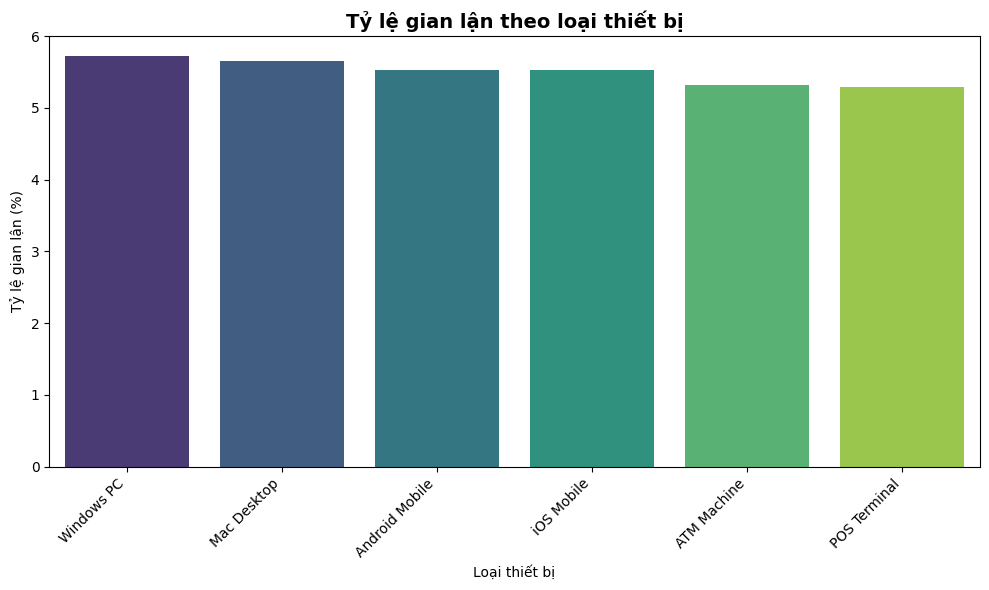

In [251]:
print("## 1. Tỷ lệ gian lận theo loại thiết bị\n")

device_fraud = df_merged.groupby('Device_Type')['Fraud_Flag'].agg(total_transactions='count', total_fraud='sum')
device_fraud['fraud_rate'] = (device_fraud['total_fraud'] / device_fraud['total_transactions']) * 100
device_fraud = device_fraud.sort_values(by='fraud_rate', ascending=False)

display(device_fraud)

plt.figure(figsize=(10, 6))
sns.barplot(x=device_fraud.index, y=device_fraud['fraud_rate'], palette='viridis')
plt.title('Tỷ lệ gian lận theo loại thiết bị', fontsize=14, weight='bold')
plt.xlabel('Loại thiết bị')
plt.ylabel('Tỷ lệ gian lận (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##Merchant nào có fraud rate cao?


## 2. Tỷ lệ gian lận theo thương gia (Top 10)



,total_transactions,total_fraud,fraud_rate
Merchant_Name,,,
Snapdeal,1987,126,6.341218
Instamart,2483,155,6.242449
Fortis Healthcare,2977,183,6.147128
Paytm Utilities,2028,124,6.114398
Tata Play,969,59,6.088751
PVR Inox,3954,240,6.069803
IRCTC,2605,158,6.065259
Croma,3003,182,6.060606
Torrent Power,3048,184,6.036745


/tmp/ipykernel_2423/4260492034.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=merchant_fraud.head(10).index, y=merchant_fraud.head(10)['fraud_rate'], palette='magma')


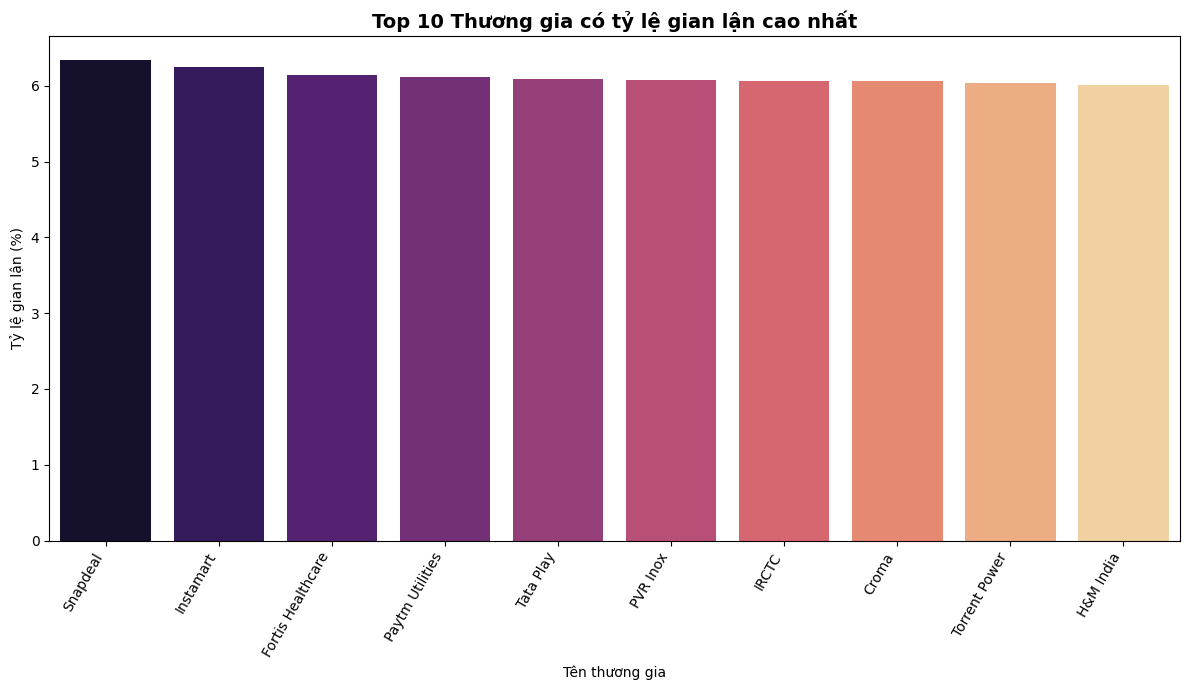

In [252]:
print("\n## 2. Tỷ lệ gian lận theo thương gia (Top 10)\n")

merchant_fraud = df_merged.groupby('Merchant_Name')['Fraud_Flag'].agg(total_transactions='count', total_fraud='sum')
# Lọc các merchant có đủ số lượng giao dịch để tính toán tỷ lệ đáng tin cậy
min_transactions_for_merchant = 50 # Ví dụ: chỉ xét các merchant có ít nhất 50 giao dịch
merchant_fraud = merchant_fraud[merchant_fraud['total_transactions'] >= min_transactions_for_merchant]
merchant_fraud['fraud_rate'] = (merchant_fraud['total_fraud'] / merchant_fraud['total_transactions']) * 100
merchant_fraud = merchant_fraud.sort_values(by='fraud_rate', ascending=False)

display(merchant_fraud.head(10)) # Hiển thị top 10 merchant có tỷ lệ gian lận cao nhất

plt.figure(figsize=(12, 7))
sns.barplot(x=merchant_fraud.head(10).index, y=merchant_fraud.head(10)['fraud_rate'], palette='magma')
plt.title('Top 10 Thương gia có tỷ lệ gian lận cao nhất', fontsize=14, weight='bold')
plt.xlabel('Tên thương gia')
plt.ylabel('Tỷ lệ gian lận (%)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

##Thành phố nào bất thường (có tỷ lệ gian lận cao)?


## 3. Tỷ lệ gian lận theo Thành phố khách hàng (Top 10)



,total_transactions,total_fraud,fraud_rate
Customer_City,,,
Surat,2366,168,7.100592
Bhubaneswar,3108,211,6.788932
KOlhapur,2346,152,6.479113
Hyderabad,2923,186,6.363325
Lucknow,2283,145,6.351292
Faridabad,3043,192,6.309563
Asansol,3651,228,6.244864
Ghaziabad,2092,130,6.214149
Aligarh,2070,128,6.183575


/tmp/ipykernel_2423/2794798025.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=customer_city_fraud.head(10).index, y=customer_city_fraud.head(10)['fraud_rate'], palette='plasma')


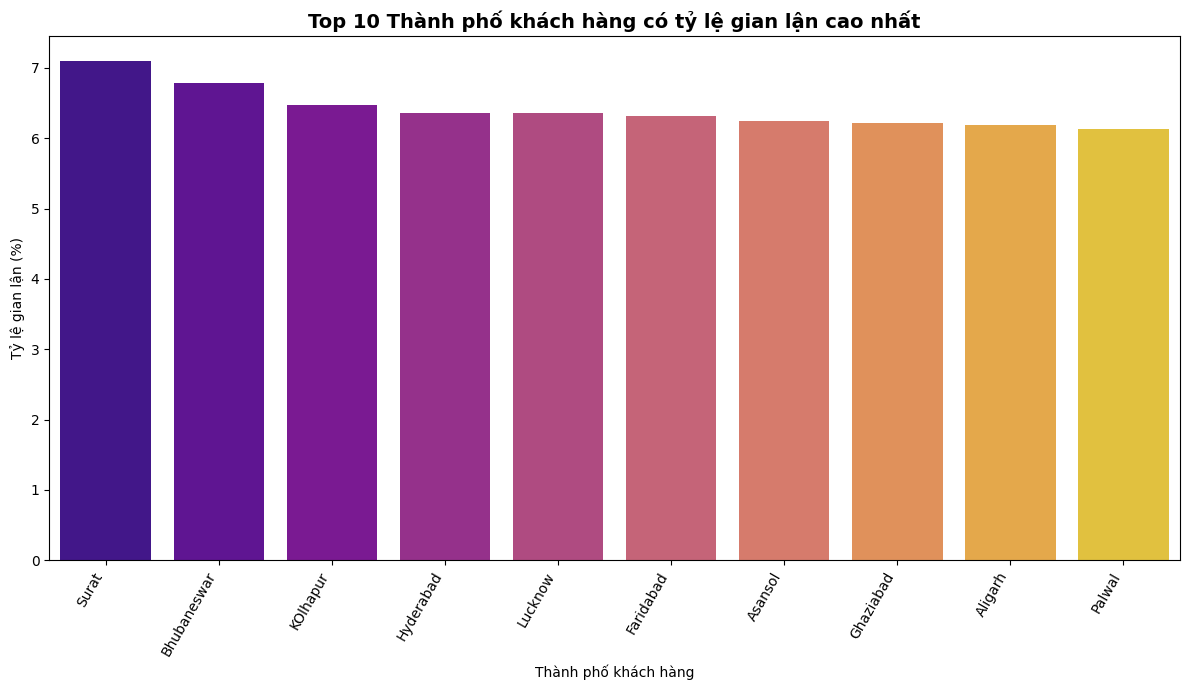


## 3. Tỷ lệ gian lận theo Thành phố thương gia (Top 10)



,total_transactions,total_fraud,fraud_rate
Merchant_City,,,
Rajkot,1000,63,6.300000
Puri,1556,98,6.298201
Nashik,2029,127,6.259241
Bhagalpur,3081,190,6.166829
Mumbai,2451,150,6.119951
Thrissur,1440,88,6.111111
Bathinda,2056,125,6.079767
Ludhiana,3523,213,6.045984
Pune,2478,148,5.972559


/tmp/ipykernel_2423/2794798025.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=merchant_city_fraud.head(10).index, y=merchant_city_fraud.head(10)['fraud_rate'], palette='crest')


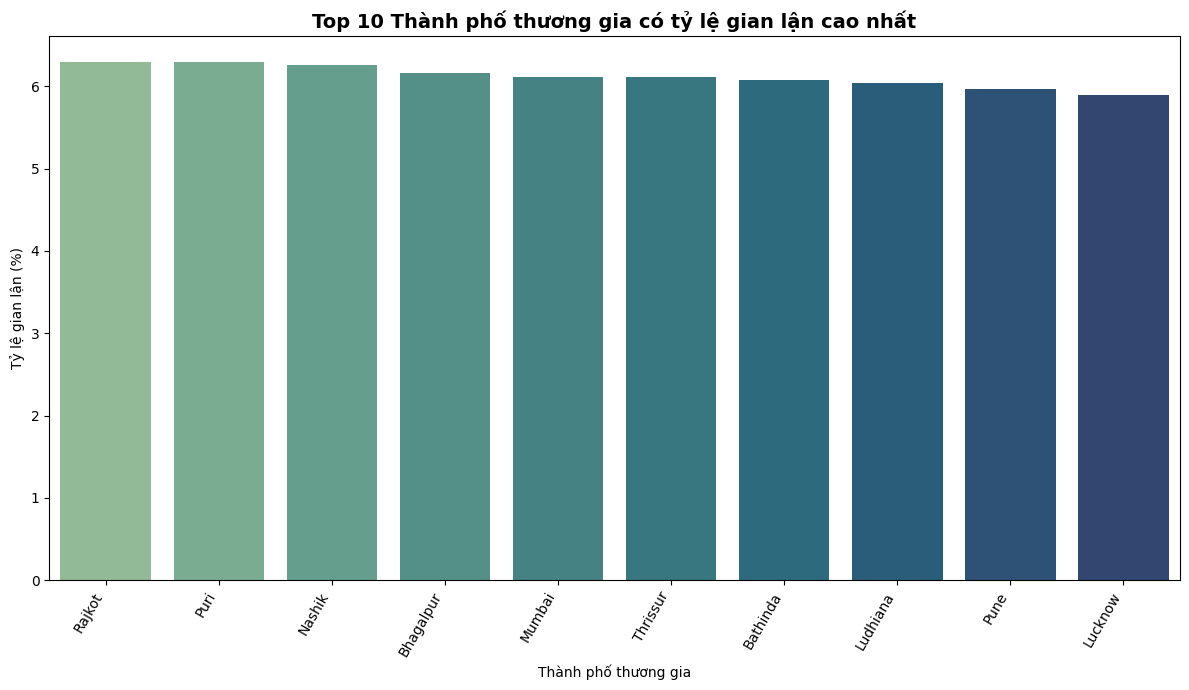

In [253]:
print("\n## 3. Tỷ lệ gian lận theo Thành phố khách hàng (Top 10)\n")

customer_city_fraud = df_merged.groupby('Customer_City')['Fraud_Flag'].agg(total_transactions='count', total_fraud='sum')
customer_city_fraud = customer_city_fraud[customer_city_fraud['total_transactions'] >= 50] # Lọc để có kết quả đáng tin cậy
customer_city_fraud['fraud_rate'] = (customer_city_fraud['total_fraud'] / customer_city_fraud['total_transactions']) * 100
customer_city_fraud = customer_city_fraud.sort_values(by='fraud_rate', ascending=False)

display(customer_city_fraud.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x=customer_city_fraud.head(10).index, y=customer_city_fraud.head(10)['fraud_rate'], palette='plasma')
plt.title('Top 10 Thành phố khách hàng có tỷ lệ gian lận cao nhất', fontsize=14, weight='bold')
plt.xlabel('Thành phố khách hàng')
plt.ylabel('Tỷ lệ gian lận (%)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

print("\n## 3. Tỷ lệ gian lận theo Thành phố thương gia (Top 10)\n")

merchant_city_fraud = df_merged.groupby('Merchant_City')['Fraud_Flag'].agg(total_transactions='count', total_fraud='sum')
merchant_city_fraud = merchant_city_fraud[merchant_city_fraud['total_transactions'] >= 50] # Lọc để có kết quả đáng tin cậy
merchant_city_fraud['fraud_rate'] = (merchant_city_fraud['total_fraud'] / merchant_city_fraud['total_transactions']) * 100
merchant_city_fraud = merchant_city_fraud.sort_values(by='fraud_rate', ascending=False)

display(merchant_city_fraud.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x=merchant_city_fraud.head(10).index, y=merchant_city_fraud.head(10)['fraud_rate'], palette='crest')
plt.title('Top 10 Thành phố thương gia có tỷ lệ gian lận cao nhất', fontsize=14, weight='bold')
plt.xlabel('Thành phố thương gia')
plt.ylabel('Tỷ lệ gian lận (%)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


##Khung giờ nào nhiều fraud?


## 4. Số lượng giao dịch gian lận theo giờ trong ngày



/tmp/ipykernel_2423/3206079207.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_merged['Transaction_Hour'] = pd.to_datetime(df_merged['Transaction_Time']).dt.hour


,total_transactions,total_fraud,fraud_rate
Transaction_Hour,,,
0,12059,700,5.804793
6,10457,592,5.661280
2,10278,585,5.691769
13,10360,584,5.637066
4,10377,580,5.589284


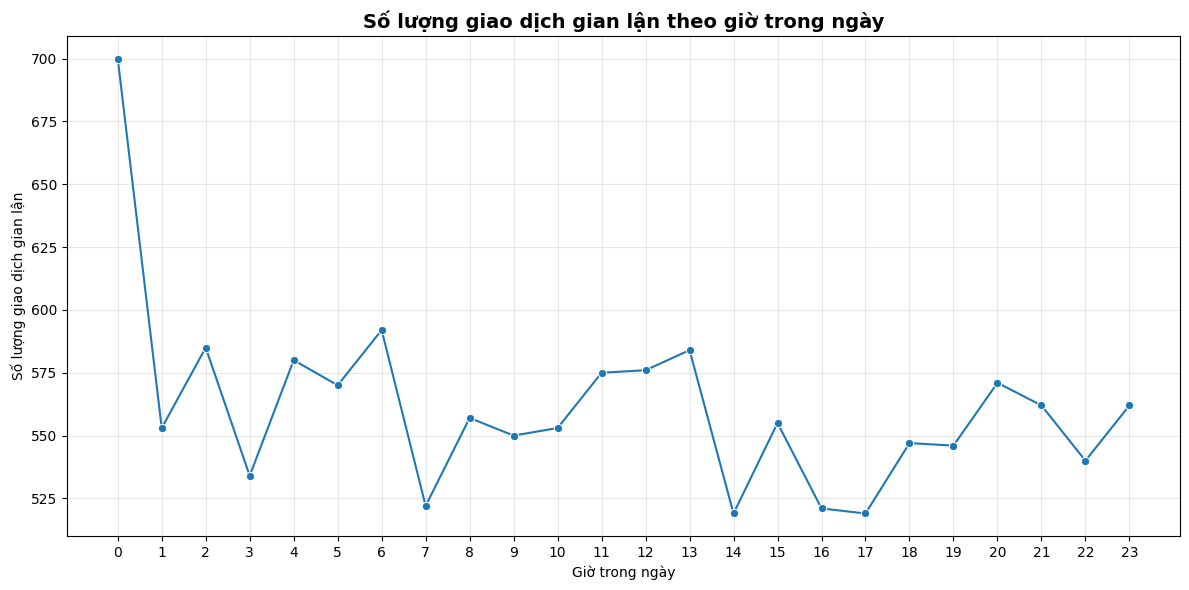

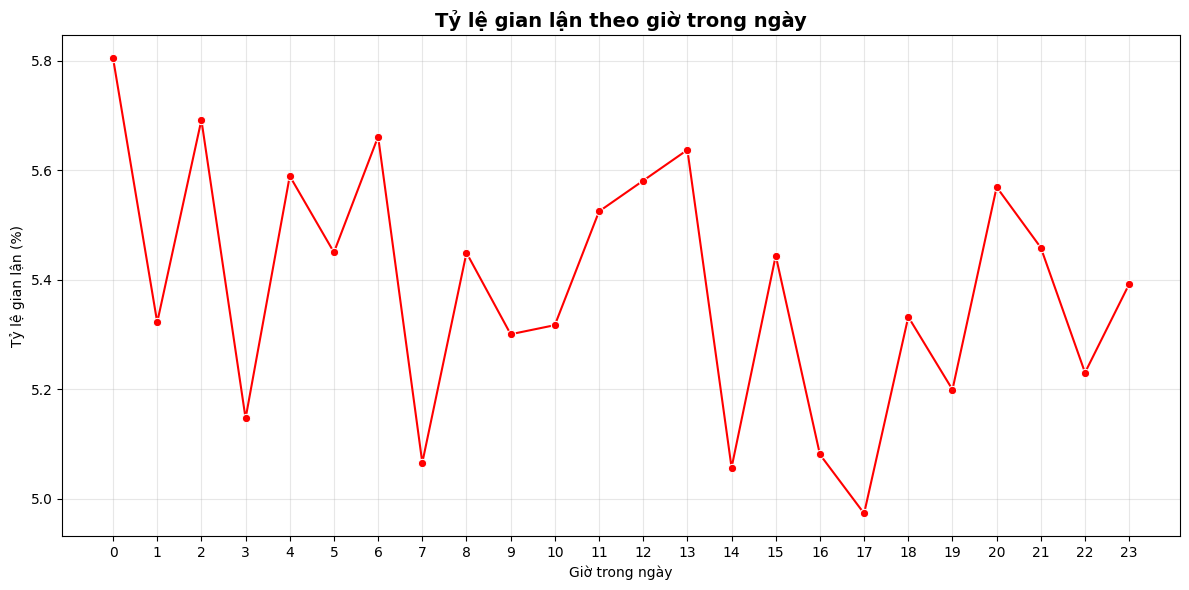

In [254]:
print("\n## 4. Số lượng giao dịch gian lận theo giờ trong ngày\n")

df_merged['Transaction_Hour'] = pd.to_datetime(df_merged['Transaction_Time']).dt.hour
hourly_fraud = df_merged.groupby('Transaction_Hour')['Fraud_Flag'].agg(total_transactions='count', total_fraud='sum')
hourly_fraud['fraud_rate'] = (hourly_fraud['total_fraud'] / hourly_fraud['total_transactions']) * 100

display(hourly_fraud.sort_values(by='total_fraud', ascending=False).head())

plt.figure(figsize=(12, 6))
sns.lineplot(x=hourly_fraud.index, y=hourly_fraud['total_fraud'], marker='o')
plt.title('Số lượng giao dịch gian lận theo giờ trong ngày', fontsize=14, weight='bold')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Số lượng giao dịch gian lận')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(x=hourly_fraud.index, y=hourly_fraud['fraud_rate'], marker='o', color='red')
plt.title('Tỷ lệ gian lận theo giờ trong ngày', fontsize=14, weight='bold')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Tỷ lệ gian lận (%)')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


##Kênh giao dịch nào nguy hiểm?


## 5. Tỷ lệ gian lận theo Kênh giao dịch



,total_transactions,total_fraud,fraud_rate
Transaction_Channel,,,
Mobile App,64991,3613,5.559231
Online Web,24823,1371,5.523104
ATM,39902,2122,5.318029
POS,120284,6367,5.293306


/tmp/ipykernel_2423/2150031842.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_fraud.index, y=channel_fraud['fraud_rate'], palette='cubehelix')


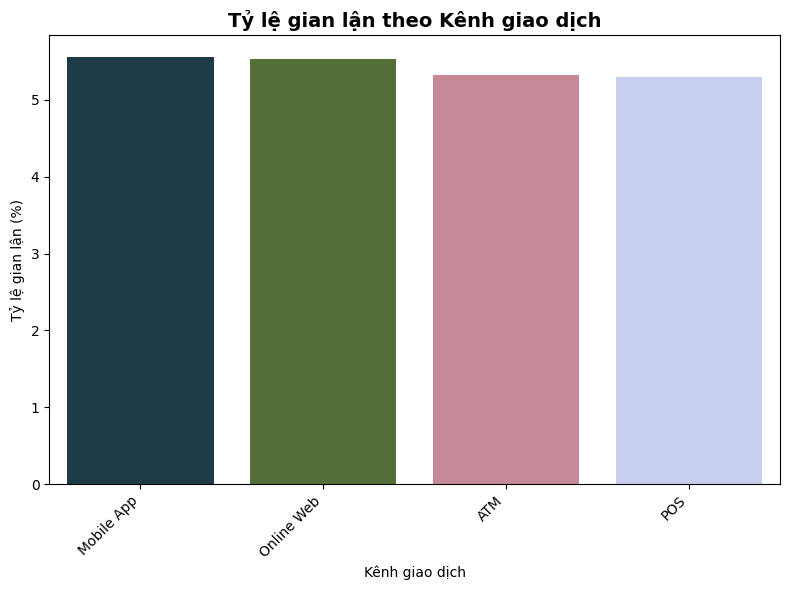

In [255]:
print("\n## 5. Tỷ lệ gian lận theo Kênh giao dịch\n")

channel_fraud = df_merged.groupby('Transaction_Channel')['Fraud_Flag'].agg(total_transactions='count', total_fraud='sum')
channel_fraud['fraud_rate'] = (channel_fraud['total_fraud'] / channel_fraud['total_transactions']) * 100
channel_fraud = channel_fraud.sort_values(by='fraud_rate', ascending=False)

display(channel_fraud)

plt.figure(figsize=(8, 6))
sns.barplot(x=channel_fraud.index, y=channel_fraud['fraud_rate'], palette='cubehelix')
plt.title('Tỷ lệ gian lận theo Kênh giao dịch', fontsize=14, weight='bold')
plt.xlabel('Kênh giao dịch')
plt.ylabel('Tỷ lệ gian lận (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Một thiết bị dùng cho bao nhiêu account?


## 6. Số lượng khách hàng duy nhất sử dụng mỗi loại thiết bị



,Customer_ID
Device_Type,
POS Terminal,20654
ATM Machine,17034
iOS Mobile,16978
Android Mobile,16946
Windows PC,3803
Mac Desktop,3799


/tmp/ipykernel_2423/887689723.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=device_customer_count.index, y=device_customer_count.values, palette='rocket')


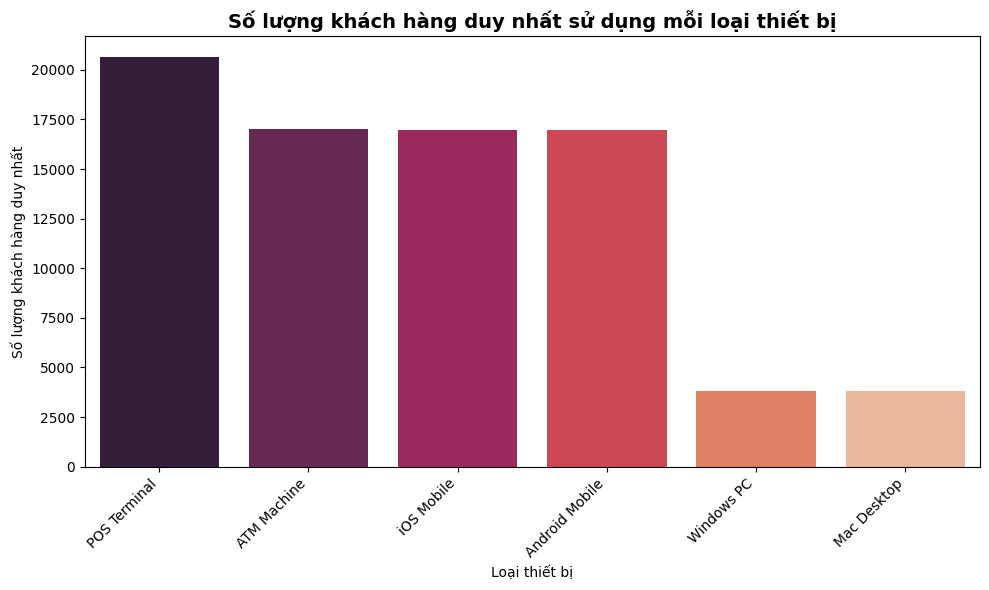

In [256]:
print("\n## 6. Số lượng khách hàng duy nhất sử dụng mỗi loại thiết bị\n")

device_customer_count = df_merged.groupby('Device_Type')['Customer_ID'].nunique()
device_customer_count = device_customer_count.sort_values(ascending=False)

display(device_customer_count)

plt.figure(figsize=(10, 6))
sns.barplot(x=device_customer_count.index, y=device_customer_count.values, palette='rocket')
plt.title('Số lượng khách hàng duy nhất sử dụng mỗi loại thiết bị', fontsize=14, weight='bold')
plt.xlabel('Loại thiết bị')
plt.ylabel('Số lượng khách hàng duy nhất')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##Một account giao dịch với bao nhiêu merchant?


## 7. Phân phối số lượng thương gia mà mỗi khách hàng giao dịch

count    24902.000000
mean         9.918360
std          5.388259
min          1.000000
25%          6.000000
50%          9.000000
75%         12.000000
max         38.000000
Name: Merchant_ID, dtype: float64


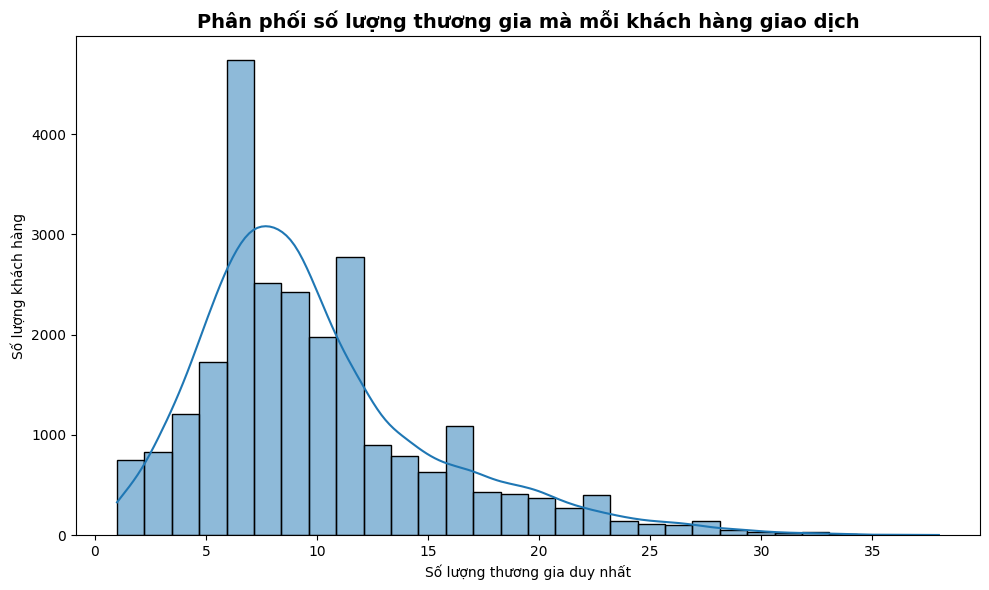

In [257]:
print("\n## 7. Phân phối số lượng thương gia mà mỗi khách hàng giao dịch\n")

merchants_per_customer = df_merged.groupby('Customer_ID')['Merchant_ID'].nunique()

print(merchants_per_customer.describe())

plt.figure(figsize=(10, 6))
sns.histplot(merchants_per_customer, bins=30, kde=True)
plt.title('Phân phối số lượng thương gia mà mỗi khách hàng giao dịch', fontsize=14, weight='bold')
plt.xlabel('Số lượng thương gia duy nhất')
plt.ylabel('Số lượng khách hàng')
plt.tight_layout()
plt.show()

## Các pattern kết hợp nào đáng chú ý?


## 8. Các mẫu kết hợp đáng chú ý (ví dụ: Merchant Category và Fraud Flag)


### 8.1. Tỷ lệ gian lận theo Danh mục Thương gia



Fraud_Flag,0,1,Fraud_Rate
Merchant_Category,,,
Entertainment,15113,906,5.655784
Utilities,11854,705,5.613504
Travel,18372,1062,5.464650
Hotel,19803,1143,5.456889
Fuel,18413,1062,5.453145
Hospital,16897,973,5.444880
Ecommerce,16592,953,5.431747
Food Delivery,15568,890,5.407704
Grocery,12254,699,5.396433


/tmp/ipykernel_2423/3697060011.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=merchant_category_fraud.index, y=merchant_category_fraud['Fraud_Rate'], palette='viridis')


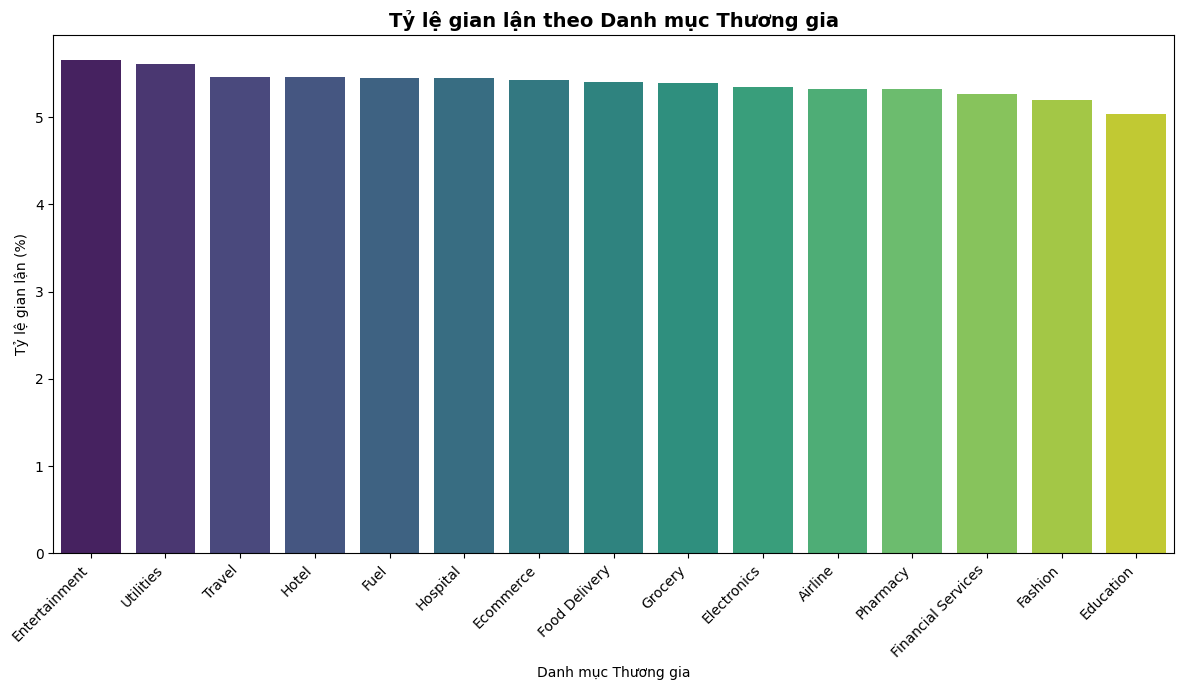


### 8.2. Tỷ lệ gian lận theo Phương thức thanh toán



Fraud_Flag,0,1,Fraud_Rate
Payment_Method,,,
Credit Card,83543,4862,5.499689
Net Banking,5796,332,5.417755
UPI,26202,1476,5.332755
Debit Card,120986,6803,5.323619


/tmp/ipykernel_2423/3697060011.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_method_fraud.index, y=payment_method_fraud['Fraud_Rate'], palette='plasma')


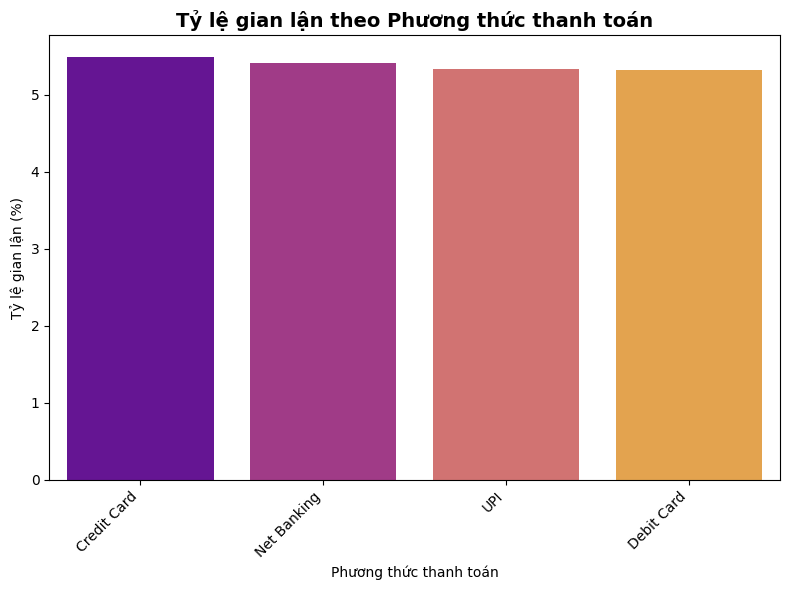


### 8.3. Tỷ lệ gian lận theo Loại thẻ



Fraud_Flag,0,1,Fraud_Rate
Card_Type,,,
Platinum,43828,2587,5.573629
Gold,72782,4145,5.388225
Classic,53933,3065,5.377382
Silver,65984,3676,5.277060


/tmp/ipykernel_2423/3697060011.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=card_type_fraud.index, y=card_type_fraud['Fraud_Rate'], palette='magma')


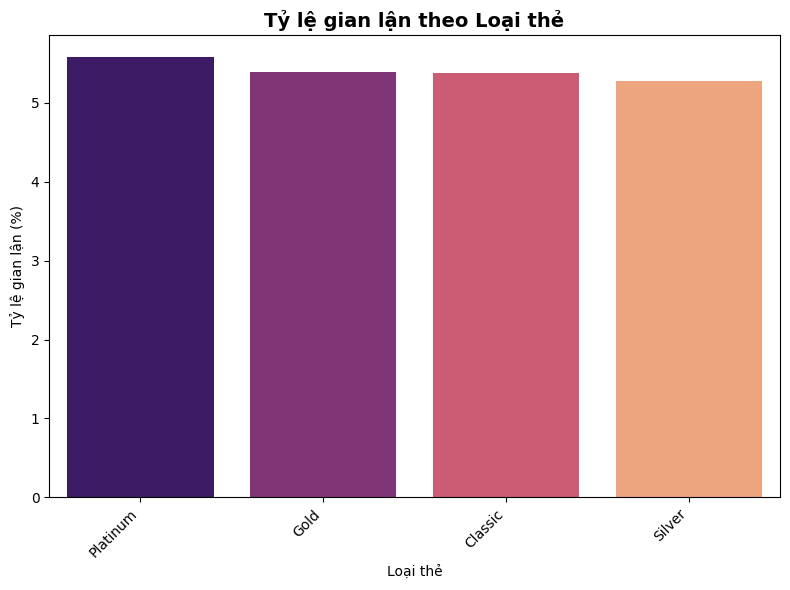

In [258]:
print("\n## 8. Các mẫu kết hợp đáng chú ý (ví dụ: Merchant Category và Fraud Flag)\n")

# Pattern 8.1: Merchant Category và Fraud Flag
merchant_category_fraud = df_merged.groupby(['Merchant_Category', 'Fraud_Flag']).size().unstack(fill_value=0)
merchant_category_fraud['Fraud_Rate'] = (merchant_category_fraud[1] / (merchant_category_fraud[0] + merchant_category_fraud[1])) * 100
merchant_category_fraud = merchant_category_fraud.sort_values(by='Fraud_Rate', ascending=False)

print("\n### 8.1. Tỷ lệ gian lận theo Danh mục Thương gia\n")
display(merchant_category_fraud)

plt.figure(figsize=(12, 7))
sns.barplot(x=merchant_category_fraud.index, y=merchant_category_fraud['Fraud_Rate'], palette='viridis')
plt.title('Tỷ lệ gian lận theo Danh mục Thương gia', fontsize=14, weight='bold')
plt.xlabel('Danh mục Thương gia')
plt.ylabel('Tỷ lệ gian lận (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Pattern 8.2: Payment Method và Fraud Flag
payment_method_fraud = df_merged.groupby(['Payment_Method', 'Fraud_Flag']).size().unstack(fill_value=0)
payment_method_fraud['Fraud_Rate'] = (payment_method_fraud[1] / (payment_method_fraud[0] + payment_method_fraud[1])) * 100
payment_method_fraud = payment_method_fraud.sort_values(by='Fraud_Rate', ascending=False)

print("\n### 8.2. Tỷ lệ gian lận theo Phương thức thanh toán\n")
display(payment_method_fraud)

plt.figure(figsize=(8, 6))
sns.barplot(x=payment_method_fraud.index, y=payment_method_fraud['Fraud_Rate'], palette='plasma')
plt.title('Tỷ lệ gian lận theo Phương thức thanh toán', fontsize=14, weight='bold')
plt.xlabel('Phương thức thanh toán')
plt.ylabel('Tỷ lệ gian lận (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Pattern 8.3: Card Type và Fraud Flag
card_type_fraud = df_merged.groupby(['Card_Type', 'Fraud_Flag']).size().unstack(fill_value=0)
card_type_fraud['Fraud_Rate'] = (card_type_fraud[1] / (card_type_fraud[0] + card_type_fraud[1])) * 100
card_type_fraud = card_type_fraud.sort_values(by='Fraud_Rate', ascending=False)

print("\n### 8.3. Tỷ lệ gian lận theo Loại thẻ\n")
display(card_type_fraud)

plt.figure(figsize=(8, 6))
sns.barplot(x=card_type_fraud.index, y=card_type_fraud['Fraud_Rate'], palette='magma')
plt.title('Tỷ lệ gian lận theo Loại thẻ', fontsize=14, weight='bold')
plt.xlabel('Loại thẻ')
plt.ylabel('Tỷ lệ gian lận (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Lưu df_merged

In [250]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Lưu file vào thư mục trên Drive
df_merged.to_csv('/content/drive/My Drive/sic_2026/indian_dataset/df_financial_after.csv', index=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
